# Import

In [1]:
import arviz as az
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pymc as pm
import random
import scipy as sp
from scipy.stats import norm
import seaborn as sns
from tqdm import tqdm
import xarray as xr

In [2]:
#pull ECCs for steel
filepath = '../EPDsFromEC3/EPD_Output/EPDs_steelstructural_2025-01-09.xlsx'
dft = pd.read_excel(filepath)
data = dft['ecc'].dropna().values

# Function definition

In [3]:
def check_array(array, data, label):
    array = np.array(array).flatten()
    a = array.shape
    b = data.shape
    if a != b:
        raise ValueError(f'{label} shape {a} must be the same as data shape {b}')
    else:
        return array.astype(float)


In [4]:
# def kde2(data,
#          xvals,
#          starting_weights='auto',
#          bandwidths='auto', 
#          confidence_weights='auto',
#          target_mean='auto',
#          target_tol='auto', 
#          represented='auto',
#          nruns=1001,
#         ):
# # starting_weights='auto'
# # bandwidths='auto'
# # confidence_weights='auto'
# # target_mean='auto'
# # target_tol='auto'
# # represented='auto'
# # nruns=1001
#     """
#     This function performs advanced KDE to a dataset, accommodating 
#     multiple sources of uncertainty and conveying a series of possible 
#     distributions as part of a Dirichlet Process.

#     INPUTS:
#         data                All data points considered for this analysis in array-like format
#         xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
#         starting_weights    Weights for each point in "data". Values in this array are automatically normalized to sum to one.
#         bandwidths          Bandwidths for each point in "data"
#         confidence_weights  Confidence for each point in "data". The percentage of weight that remains unchanged
#         target_mean         The desired mean of the overall distribution
#         target_tol          The standard deviation of "target_mean"
#         represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
#         nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

#     OUTPUTS:
#         totals              Array of (nruns * xvals) representing all resulting probability density functions
#         dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
#     """
#     ####################################################################################
#     ######################  CHECK INPUT DATA ###########################################
#     ####################################################################################
#     data = np.array(data).flatten()
#     lst1 = []
#     lst2 = []
#     #check starting weights
#     if type(starting_weights) == str and starting_weights == 'auto':
#         starting_weights = np.zeros_like(data) + 1/len(data)
#         print('starting_weights has defaulted to uniform for all data points.')
#     else:
#         starting_weights = check_array(starting_weights, data, 'starting_weights')
#         starting_weights /= sum(starting_weights)

#     #check bandwidths
#     base_expval = sum(data*starting_weights)/sum(starting_weights)
#     base_std = np.sqrt(sum(starting_weights*(data-sum(data*starting_weights)/sum(starting_weights))**2)/sum(starting_weights))
#     cdf = starting_weights.copy()    
#     y_cdf, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
#     y_cdf, cdf = np.array(y_cdf), np.array(cdf)
#     for i in range(len(cdf)-1):
#         cdf[i+1] = cdf[i] + starting_weights[i]
#     cdf[0] = 0
#     cdf[-1] = 1
#     perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
#     iqr = perc2val(0.75)-perc2val(0.25)
#     base_bw = 0.9 * min([base_std, iqr/1.35]) * len(data)**-0.2
#     if type(bandwidths) == str and bandwidths == 'auto':
#         bandwidths = np.zeros_like(data) + base_bw
#         print('bandwidths has defaulted to the Silverman method for all data points.')

#     else:
#         bandwidths = check_array(bandwidths, data, 'bandwidths')

#     #check confidence_weights
#     if type(confidence_weights) == str and confidence_weights == 'auto':
#         confidence_weights = np.zeros_like(data) + 0.5
#         print(f'confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
#     else:
#         confidence_weights = check_array(confidence_weights, data, 'confidence_weights')

#     #check target_mean
#     if type(target_mean) == str and target_mean == 'auto':
#         target_mean = base_expval
#         print(f'target_mean has defaulted to the weighted average of the dataset.')

#     #check target_tol
#     if type(target_tol) == str and target_tol == 'auto':
#         target_tol = base_std
#         print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

#     #check represented
#     if type(represented) == str and represented == 'auto':
#         represented = 0.6
#         print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
#     elif represented > 1 or represented < 0:
#         raise ValueError("The variable 'represented' must be a value between 0 and 1")

#     #check xvals - must be an array of custom values
#     if len(xvals) == nruns:
#         nruns += 1
#         print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')


#     ####################################################################################
#     ######################  FUNCTION STARTS HERE #######################################
#     ####################################################################################

#     #collect metadata
#     n = 10
#     all_weights = np.zeros(shape=(nruns,len(data)+n))
#     all_means = np.zeros(shape=(nruns,len(data)+n))
#     all_expval = np.zeros_like(range(nruns))
#     totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))
#     for i in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):
#         # remove unrepresented data
#         weights = starting_weights*represented
#         bandwidths = bandwidths[:len(weights)]
#         confidence_weights = confidence_weights[:len(weights)]

#         # randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
#         # means = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
#         # while min(means) < 0:
#         #     ind = np.where(means==min(means))[0][0]
#         #     means[ind] = np.random.normal(data[ind], bandwidths)
#         means = data

#         # add new values to means to represent unrepresented data
#         target = np.random.normal(target_mean, target_tol)
#         while target < 0:
#             target = np.random.normal(target_mean, target_tol)

#         # pick where to add new values and what to assign them
#         if target >= sum(means*weights)/sum(weights): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
#             new_means = abs(np.random.normal(0,1,n))
#             new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
#             new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
#             factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
#             new_means = target + new_means*factor
#         elif target / (sum(means*weights)/sum(weights)) > represented: # target is less than expected value, but can still be reached with random values
#             new_means = np.random.uniform(0, 1, size=n)
#             new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
#             goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
#             current_avg = sum(new_means*new_weights)/sum(new_weights)
#             factor = goal_avg/current_avg
#             new_means *= factor
#         else: # positive values cannot help achieve our target, add big lump at zero
#             new_means = np.array([0]*n)
#             new_weights = np.array([(1-represented)/n]*n)

#         weights = np.concatenate((weights, new_weights))
#         means = np.concatenate((means, new_means))
#         bandwidths = np.concatenate((bandwidths, np.zeros(len(new_means)) + base_bw))
#         confidence_weights = np.concatenate((confidence_weights, np.zeros(len(new_means))))

#         # separate into lower and higher than target. Preserve order of means and weights so they still match
#         weights *= confidence_weights
#         means_lo, weights_lo = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean < target]).T
#         means_hi, weights_hi = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean >= target]).T

#         #pare down existing weights according to our confidence
#         leftover_weight = 1-sum(weights)

#         # Get random values that will apply to the low and high means
#         # rand_lo = np.random.beta(a=0.5, b=0.5, size=len(means_lo))
#         # rand_hi = np.random.beta(a=0.5, b=0.5, size=len(means_hi))

#         rand_lo = np.random.dirichlet(np.ones(len(means_lo)),1)[0]*leftover_weight
#         rand_hi = np.random.dirichlet(np.ones(len(means_hi)),1)[0]*leftover_weight

#         # find out weighted mean if all leftover_weight goes to low or if all goes to high
#         lo = sum(means_lo*(rand_lo + weights_lo)) + sum(means_hi*weights_hi)
#         hi = sum(means_hi*(rand_hi + weights_hi)) + sum(means_lo*weights_lo)

#         # # find the proximity of the target relative to the weighted average of lower values. randomize according to target tolerance.
#         prox_lo = (target-lo)/(hi-lo)
#         if prox_lo < 0:
#             prox_lo = 0
#         elif prox_lo > 1:
#             prox_lo = 1

#         lst1.append(prox_lo)
#         # # adjust weights according to our randomized proximity value
#         weights_lo = weights_lo + rand_lo*(1-prox_lo)
#         weights_hi = weights_hi + rand_hi*prox_lo

#         # # put low and high weights and means back into the same array
#         weights = np.concatenate((weights_lo, weights_hi))
#         means = np.concatenate((means_lo, means_hi))

#         all_weights[i] = weights
#         all_means[i] = means
#         all_expval[i] = sum(means*weights)/sum(weights)

#         #evaluate all means
#         yvals = norm.pdf(xvals.reshape(-1,1), means, bandwidths)*weights
#         totals[i] = sum(yvals.T)
#         totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

#     dict_analytics = {}
#     dict_analytics['all_means'] = all_means
#     dict_analytics['all_weights'] = all_means
#     dict_analytics['all_expval'] = all_expval


#     return totals, dict_analytics, lst1

In [5]:
def kde2(data,
         xvals,
         starting_weights='auto',
         bandwidths='auto', 
         confidence_weights='auto',
         target_mean='auto',
         target_tol='auto', 
         represented='auto',
         nruns=1001,
        ):
# starting_weights='auto'
# bandwidths='auto'
# confidence_weights='auto'
# target_mean='auto'
# target_tol='auto'
# represented='auto'
# nruns=1001
    """
    This function performs advanced KDE to a dataset, accommodating 
    multiple sources of uncertainty and conveying a series of possible 
    distributions as part of a Dirichlet Process.

    INPUTS:
        data                All data points considered for this analysis in array-like format
        xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
        starting_weights    Weights for each point in "data". Values in this array are automatically normalized to sum to one.
        bandwidths          Bandwidths for each point in "data"
        confidence_weights  Confidence for each point in "data". The percentage of weight that remains unchanged
        target_mean         The desired mean of the overall distribution
        target_tol          The standard deviation of "target_mean"
        represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
        nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

    OUTPUTS:
        totals              Array of (nruns * xvals) representing all resulting probability density functions
        dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
    """
    ####################################################################################
    ######################  CHECK INPUT DATA ###########################################
    ####################################################################################
    data = np.array(data).flatten()
    lst1 = []
    lst2 = []
    #check starting weights
    if type(starting_weights) == str and starting_weights == 'auto':
        starting_weights = np.zeros_like(data) + 1/len(data)
        print('starting_weights has defaulted to uniform for all data points.')
    else:
        starting_weights = check_array(starting_weights, data, 'starting_weights')
        starting_weights /= sum(starting_weights)

    #check bandwidths
    base_expval = sum(data*starting_weights)/sum(starting_weights)
    base_std = np.sqrt(sum(starting_weights*(data-sum(data*starting_weights)/sum(starting_weights))**2)/sum(starting_weights))
    cdf = starting_weights.copy()    
    y_cdf, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
    y_cdf, cdf = np.array(y_cdf), np.array(cdf)
    for i in range(len(cdf)-1):
        cdf[i+1] = cdf[i] + starting_weights[i]
    cdf[0] = 0
    cdf[-1] = 1
    perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
    iqr = perc2val(0.75)-perc2val(0.25)
    base_bw = 0.9 * min([base_std, iqr/1.35]) * len(data)**-0.2
    if type(bandwidths) == str and bandwidths == 'auto':
        bandwidths = np.zeros_like(data) + base_bw
        print('bandwidths has defaulted to the Silverman method for all data points.')

    else:
        bandwidths = check_array(bandwidths, data, 'bandwidths')

    #check confidence_weights
    if type(confidence_weights) == str and confidence_weights == 'auto':
        confidence_weights = np.zeros_like(data) + 0.5
        print(f'confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
    else:
        confidence_weights = check_array(confidence_weights, data, 'confidence_weights')

    #check target_mean
    if type(target_mean) == str and target_mean == 'auto':
        target_mean = base_expval
        print(f'target_mean has defaulted to the weighted average of the dataset.')

    #check target_tol
    if type(target_tol) == str and target_tol == 'auto':
        target_tol = base_std
        print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

    #check represented
    if type(represented) == str and represented == 'auto':
        represented = 0.6
        print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
    elif represented > 1 or represented < 0:
        raise ValueError("The variable 'represented' must be a value between 0 and 1")

    #check xvals - must be an array of custom values
    if len(xvals) == nruns:
        nruns += 1
        print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')


    ####################################################################################
    ######################  FUNCTION STARTS HERE #######################################
    ####################################################################################

    #collect metadata
    n = 10
    all_weights = np.zeros(shape=(nruns,len(data)+n))
    all_means = np.zeros(shape=(nruns,len(data)+n))
    all_expval = np.zeros_like(range(nruns))
    totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))
    for i in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):
        # remove unrepresented data
        weights = starting_weights*represented
        bandwidths = bandwidths[:len(weights)]
        confidence_weights = confidence_weights[:len(weights)]

        # randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
        # means = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
        # while min(means) < 0:
        #     ind = np.where(means==min(means))[0][0]
        #     means[ind] = np.random.normal(data[ind], bandwidths)
        means = data

        # add new values to means to represent unrepresented data
        target = np.random.normal(target_mean, target_tol)
        while target < 0:
            target = np.random.normal(target_mean, target_tol)

        # pick where to add new values and what to assign them
        if target >= sum(means*weights)/sum(weights): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
            new_means = abs(np.random.normal(0,1,n))
            new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
            new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
            factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
            new_means = target + new_means*factor
        elif target / (sum(means*weights)/sum(weights)) > represented: # target is less than expected value, but can still be reached with random values
            new_means = np.random.uniform(0, 1, size=n)
            new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
            goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
            current_avg = sum(new_means*new_weights)/sum(new_weights)
            factor = goal_avg/current_avg
            new_means *= factor
        else: # positive values cannot help achieve our target, add big lump at zero
            new_means = np.array([0]*n)
            new_weights = np.array([(1-represented)/n]*n)

        weights = np.concatenate((weights, new_weights))
        means = np.concatenate((means, new_means))
        bandwidths = np.concatenate((bandwidths, np.zeros(len(new_means)) + base_bw))
        confidence_weights = np.concatenate((confidence_weights, np.zeros(len(new_means))))

        # separate into lower and higher than target. Preserve order of means and weights so they still match
        weights *= confidence_weights
        
        weights = generate_feasible_samples(x=means, S=target, min_weights=weights, group_constraints=None, num_samples=1, max_attempts=10_000)
        

        # track each mean, weight, and expected value
        all_weights[i] = weights
        all_means[i] = means
        all_expval[i] = sum(means*weights)/sum(weights)

        #evaluate all means
        yvals = norm.pdf(xvals.reshape(-1,1), means, bandwidths)*weights
        totals[i] = sum(yvals.T)
        totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

    dict_analytics = {}
    dict_analytics['all_means'] = all_means
    dict_analytics['all_weights'] = all_means
    dict_analytics['all_expval'] = all_expval


    return totals, dict_analytics, lst1

In [6]:
xvals = np.linspace(
    min(data)-np.std(data)*3,
    max(data)+np.std(data)*3,
    1_000,
)
starting_weights='auto'
bandwidths='auto'
confidence_weights='auto'
target_mean='auto'
target_tol='auto'
represented='auto'
nruns=10

"""
This function performs advanced KDE to a dataset, accommodating 
multiple sources of uncertainty and conveying a series of possible 
distributions as part of a Dirichlet Process.

INPUTS:
    data                All data points considered for this analysis in array-like format
    xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
    starting_weights    Weights for each point in "data". Values in this array are automatically normalized to sum to one.
    bandwidths          Bandwidths for each point in "data"
    confidence_weights  Confidence for each point in "data". The percentage of weight that remains unchanged
    target_mean         The desired mean of the overall distribution
    target_tol          The standard deviation of "target_mean"
    represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
    nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

OUTPUTS:
    totals              Array of (nruns * xvals) representing all resulting probability density functions
    dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
"""
####################################################################################
######################  CHECK INPUT DATA ###########################################
####################################################################################
data = np.array(data).flatten()
lst1 = []
lst2 = []
#check starting weights
if type(starting_weights) == str and starting_weights == 'auto':
    starting_weights = np.zeros_like(data) + 1/len(data)
    print('starting_weights has defaulted to uniform for all data points.')
else:
    starting_weights = check_array(starting_weights, data, 'starting_weights')
    starting_weights /= sum(starting_weights)

#check bandwidths
base_expval = sum(data*starting_weights)/sum(starting_weights)
base_std = np.sqrt(sum(starting_weights*(data-sum(data*starting_weights)/sum(starting_weights))**2)/sum(starting_weights))
cdf = starting_weights.copy()    
y_cdf, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
y_cdf, cdf = np.array(y_cdf), np.array(cdf)
for i in range(len(cdf)-1):
    cdf[i+1] = cdf[i] + starting_weights[i]
cdf[0] = 0
cdf[-1] = 1
perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
iqr = perc2val(0.75)-perc2val(0.25)
base_bw = 0.9 * min([base_std, iqr/1.35]) * len(data)**-0.2
if type(bandwidths) == str and bandwidths == 'auto':
    bandwidths = np.zeros_like(data) + base_bw
    print('bandwidths has defaulted to the Silverman method for all data points.')

else:
    bandwidths = check_array(bandwidths, data, 'bandwidths')

#check confidence_weights
if type(confidence_weights) == str and confidence_weights == 'auto':
    confidence_weights = np.zeros_like(data) + 0.5
    print(f'confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
else:
    confidence_weights = check_array(confidence_weights, data, 'confidence_weights')

#check target_mean
if type(target_mean) == str and target_mean == 'auto':
    target_mean = base_expval
    print(f'target_mean has defaulted to the weighted average of the dataset.')

#check target_tol
if type(target_tol) == str and target_tol == 'auto':
    target_tol = base_std
    print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

#check represented
if type(represented) == str and represented == 'auto':
    represented = 0.6
    print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
elif represented > 1 or represented < 0:
    raise ValueError("The variable 'represented' must be a value between 0 and 1")

#check xvals - must be an array of custom values
if len(xvals) == nruns:
    nruns += 1
    print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')


####################################################################################
######################  FUNCTION STARTS HERE #######################################
####################################################################################

#collect metadata
n = 10
all_weights = np.zeros(shape=(nruns,len(data)+n))
all_means = np.zeros(shape=(nruns,len(data)+n))
all_expval = np.zeros_like(range(nruns))
totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))
# for i in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):




# remove unrepresented data
weights = starting_weights*represented
bandwidths = bandwidths[:len(weights)]
confidence_weights = confidence_weights[:len(weights)]
# randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
# means = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
# while min(means) < 0:
#     ind = np.where(means==min(means))[0][0]
#     means[ind] = np.random.normal(data[ind], bandwidths)
means = data

# add new values to means to represent unrepresented data
target = np.random.normal(target_mean, target_tol)
while target < 0:
    target = np.random.normal(target_mean, target_tol)

# pick where to add new values and what to assign them
if target >= sum(means*weights)/sum(weights): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
    new_means = abs(np.random.normal(0,1,n))
    new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
    new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
    factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
    new_means = target + new_means*factor
elif target / (sum(means*weights)/sum(weights)) > represented: # target is less than expected value, but can still be reached with random values
    new_means = np.random.uniform(0, 1, size=n)
    new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
    goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
    current_avg = sum(new_means*new_weights)/sum(new_weights)
    factor = goal_avg/current_avg
    new_means *= factor
else: # positive values cannot help achieve our target, add big lump at zero
    new_means = np.array([0]*n)
    new_weights = np.array([(1-represented)/n]*n)

weights = np.concatenate((weights, new_weights))
means = np.concatenate((means, new_means))
bandwidths = np.concatenate((bandwidths, np.zeros(len(new_means)) + base_bw))
confidence_weights = np.concatenate((confidence_weights, np.zeros(len(new_means))))

# separate into lower and higher than target. Preserve order of means and weights so they still match
weights *= confidence_weights

weights2 = generate_feasible_samples(x=means, S=target, min_weights=weights, group_constraints=None, num_samples=1, max_attempts=10_000)


# track each mean, weight, and expected value
all_weights[i] = weights2
all_means[i] = means
all_expval[i] = sum(means*weights2)/sum(weights2)

#evaluate all means
yvals = norm.pdf(xvals.reshape(-1,1), means, bandwidths)*weights2
totals[i] = sum(yvals.T)
totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

dict_analytics = {}
dict_analytics['all_means'] = all_means
dict_analytics['all_weights'] = all_means
dict_analytics['all_expval'] = all_expval

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


NameError: name 'generate_feasible_samples' is not defined

In [ ]:
target = 2

generate_feasible_samples(x=means, S=target, min_weights=weights, group_constraints=None, num_samples=1_000, max_attempts=1_000_000)


In [1070]:
x = data
min_weights = weights

# Check feasibility: S must be within the convex hull of x values
S_min = np.sum(min_weights*x) + min(x)*(1-sum(min_weights))
S_max = np.sum(min_weights*x) + max(x)*(1-sum(min_weights))
if not (S_min <= S <= S_max):
    raise ValueError(f"S={S} is out of feasible range [{S_min}, {S_max}]")


ValueError: operands could not be broadcast together with shapes (19,) (133,) 

In [1044]:

# S_min = np.sum(min_weights*x) + min(x)*(1-sum(min_weights))
# S_max = np.sum(min_weights*x) + max(x)*(1-sum(min_weights))

array([], dtype=float64)

In [1025]:
%%time
xvals = np.linspace(
    min(data)-np.std(data)*3,
    max(data)+np.std(data)*3,
    1_000,
)
totals, dict_analytics, lst1 = kde2(
    data = data,
    xvals = xvals,
     # starting_weights,
     # bandwidths,
     # confidence_weights,
     # target_mean,
     # target_tol, 
     # represented, 
     # xvals='',
     nruns=1001)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS:   0%|          | 0/1001 [00:00<?, ?it/s]


0/10000 = 0.0%


ValueError: could not broadcast input array from shape (0,) into shape (19,)

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

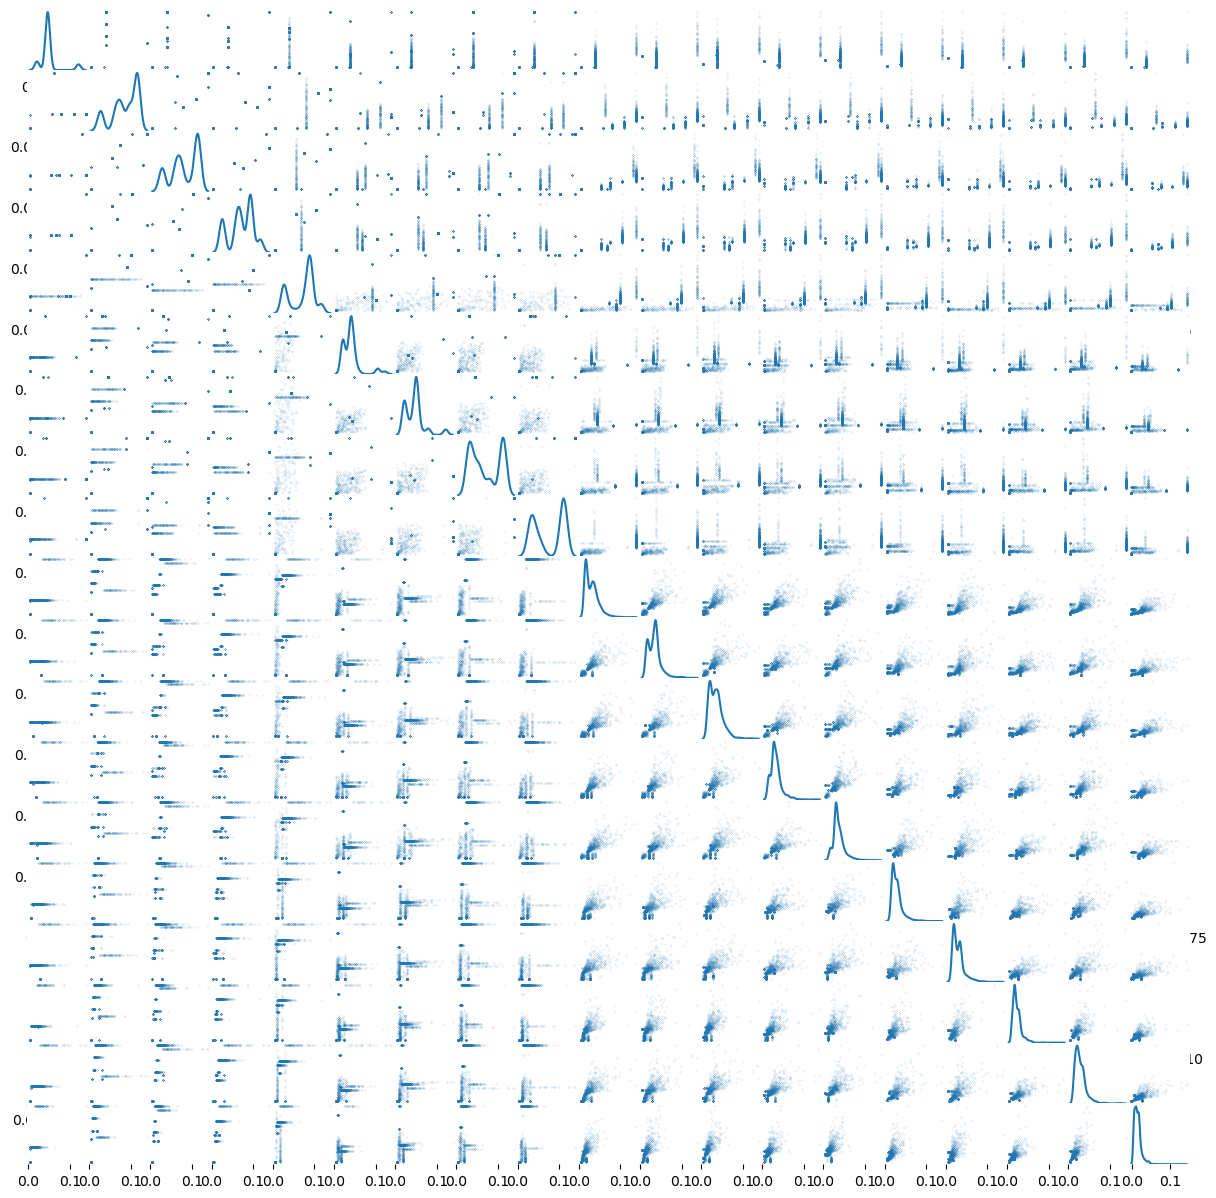

In [897]:
# results = samples.T
results = dict_analytics['all_weights'].T
N = len(results)

# fig, axes = plt.subplots(N, N, figsize=(15,15), sharex=True, gridspec_kw=dict(hspace=0, wspace=0))
fig, axes = plt.subplots(N, N, figsize=(15,15), gridspec_kw=dict(hspace=0, wspace=0))
for i, j in product(range(N), range(N)):
    ax = axes[i, j]
    if i == j:
        sns.kdeplot(results[i], ax=ax)
        # ax.set_xlim(-0.1,1.1)
    else:
        ax.scatter(results[i], results[j], alpha=1, s=0.005)
        # ax.set_xlim(0,1)
        # ax.set_ylim(0,1)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.get_yaxis().set_visible(False)


# Plot

## Definitions

In [11]:
%%time
def kde2_plot(totals, ax, nruns=1000):
    lo = 0.1
    hi = 0.9
    qlo = np.quantile(totals, lo, axis=0)
    q50 = np.quantile(totals, 0.50, axis=0)
    qhi = np.quantile(totals, hi, axis=0)

    color = 'tab:red'

    # fig, ax = plt.subplots(1,1)
    #plot regular kde applied to data
    sns.kdeplot(data=data, bw_method='silverman', label='Regular KDE', ax=ax)

    # plot simulations
    ax.plot(xvals, totals.T, alpha=0.01, color='black');
    ax.plot(xvals, q50, alpha=0.5, color='gray', label=f"{nruns} simulations");

    # plot quartiles
    ax.plot(xvals, q50/sp.integrate.trapezoid(q50, xvals), color=color, label='Median');
    ax.plot(xvals, qlo, color=color, linestyle='--', label=f"{int(np.round(lo*100,0))}-{int(np.round(hi*100,0))}%");
    ax.plot(xvals, qhi, color=color, linestyle='--');
    ax.fill_between(xvals, qlo, qhi, color=color, alpha=0.5)


    # format
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(True)
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5));
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.vlines(x=0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='black');
    ax.hlines(y=0, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='black');

CPU times: user 6 μs, sys: 2 μs, total: 8 μs
Wall time: 15 μs


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


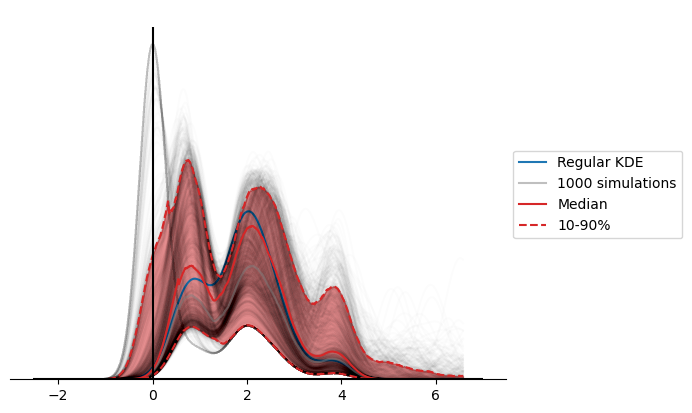

In [12]:
fig, ax = plt.subplots()
kde2_plot(totals, ax)

## starting_weights

In [13]:
#different starting_weights
data.sort()
totals = []
options = [
    np.arange(1,len(data)+1),
    'auto',
    np.arange(len(data),0,-1),
]

adj = 0.9
confidence_weights = np.zeros_like(data) + adj
represented = adj

xvals = np.linspace(-1, 5, 1_000)

for starting_weights in options:
    total = kde2(data=data, xvals=xvals, starting_weights=starting_weights, confidence_weights=confidence_weights, represented=represented)[0]
    totals.append(total)

bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:06<00:00, 147.06it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:06<00:00, 149.67it/s]


bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:06<00:00, 149.71it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


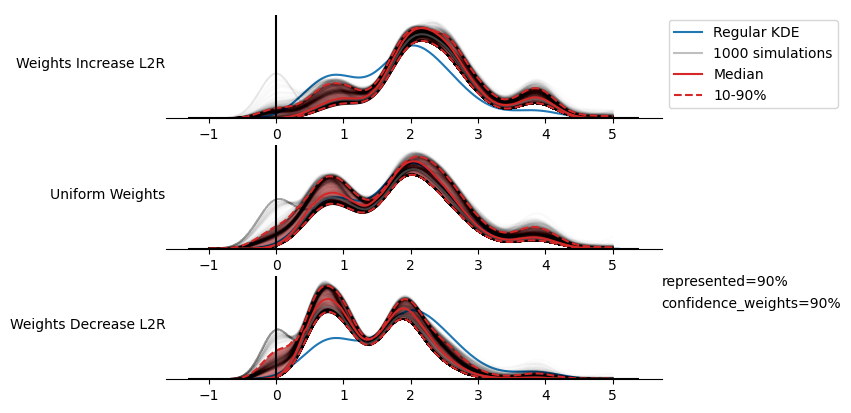

In [14]:
fig, axes = plt.subplots(len(options),1)

for i, sw in enumerate(options):
    ax = axes[i]
    kde2_plot(totals[i], ax)
    if i > 0:
        ax.legend().set_visible(False)

ax = axes[0]
ax.text(x=0, y=0.5, s='Weights Increase L2R', ha='right', va='center', transform=ax.transAxes)

ax = axes[1]
ax.text(x=0, y=0.5, s='Uniform Weights', ha='right', va='center', transform=ax.transAxes)

ax = axes[2]
ax.text(x=0, y=0.5, s='Weights Decrease L2R', ha='right', va='center', transform=ax.transAxes)
ax.text(x=1, y=0.9, s=f'represented={int(np.round(adj,2)*100)}%', ha='left', va='center', transform=ax.transAxes);
ax.text(x=1, y=0.7, s=f'confidence_weights={int(np.round(adj,2)*100)}%', ha='left', va='center', transform=ax.transAxes);


## bandwidths

In [513]:
#different bandwidths
data.sort()
totals = []
iqr = np.quantile(data,0.75) - np.quantile(data, 0.25)
bw = 0.9 * min([np.std(data), iqr/1.35]) * len(data)**-0.2
options = [
    np.zeros_like(data) + bw*3,
    np.zeros_like(data) + bw,
    np.zeros_like(data) + bw/3,
]

adj = 0.9
confidence_weights = np.zeros_like(data) + adj
represented = adj

xvals = np.linspace(
    min(data)-np.std(data)*3,
    max(data)+np.std(data)*3,
    1_000,
)
xvals = np.linspace(-1, 5, 1_000)
for bandwidths in options:
    total = kde2(data=data, xvals=xvals, bandwidths=bandwidths, confidence_weights=confidence_weights, represented=represented)[0]
    totals.append(total)

starting_weights has defaulted to uniform for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 253.57it/s]


starting_weights has defaulted to uniform for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 275.24it/s]


starting_weights has defaulted to uniform for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 228.93it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


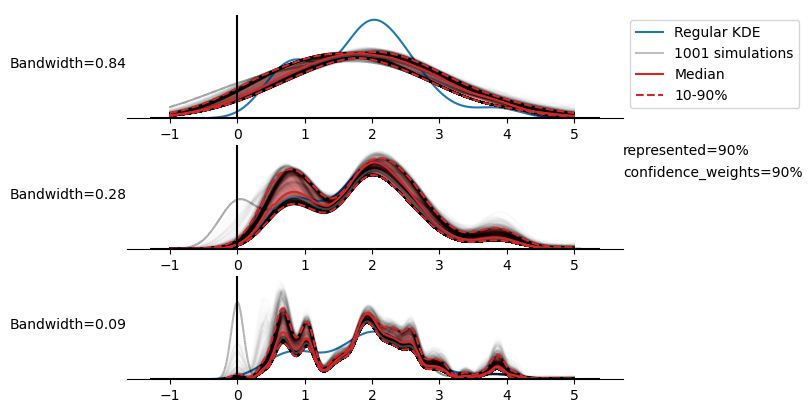

In [514]:
fig, axes = plt.subplots(len(options),1)

for i, bw in enumerate(options):
    bw = bw[0]
    ax = axes[i]
    kde2_plot(totals[i], ax)
    ax.text(x=0, y=0.5, s=f'Bandwidth={np.round(bw,2)}', ha='right', va='center', transform=ax.transAxes)
    if i > 0:
        ax.legend().set_visible(False)

ax = axes[1]

ax.text(x=1, y=0.9, s=f'represented={int(np.round(adj,2)*100)}%', ha='left', va='center', transform=ax.transAxes);
ax.text(x=1, y=0.7, s=f'confidence_weights={int(np.round(adj,2)*100)}%', ha='left', va='center', transform=ax.transAxes);


## confidence_weights

In [526]:
#different confidence_weights
data.sort()
totals = []
iqr = np.quantile(data,0.75) - np.quantile(data, 0.25)
bw = 0.9 * min([np.std(data), iqr/1.35]) * len(data)**-0.2
options = [
    np.zeros_like(data) + 5/6,
    np.zeros_like(data) + 4/6,
    np.zeros_like(data) + 3/6,
    np.zeros_like(data) + 2/6,
    np.zeros_like(data) + 1/6,
]

represented = 0.9
xvals = np.linspace(-1, 6, 1_000)
target_mean = np.mean(data)*1.5

for confidence_weights in options:
    total = kde2(data=data, xvals=xvals, confidence_weights=confidence_weights, target_mean=target_mean, represented=represented)[0]
    totals.append(total)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 291.59it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 290.66it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 253.22it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 308.06it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 304.75it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

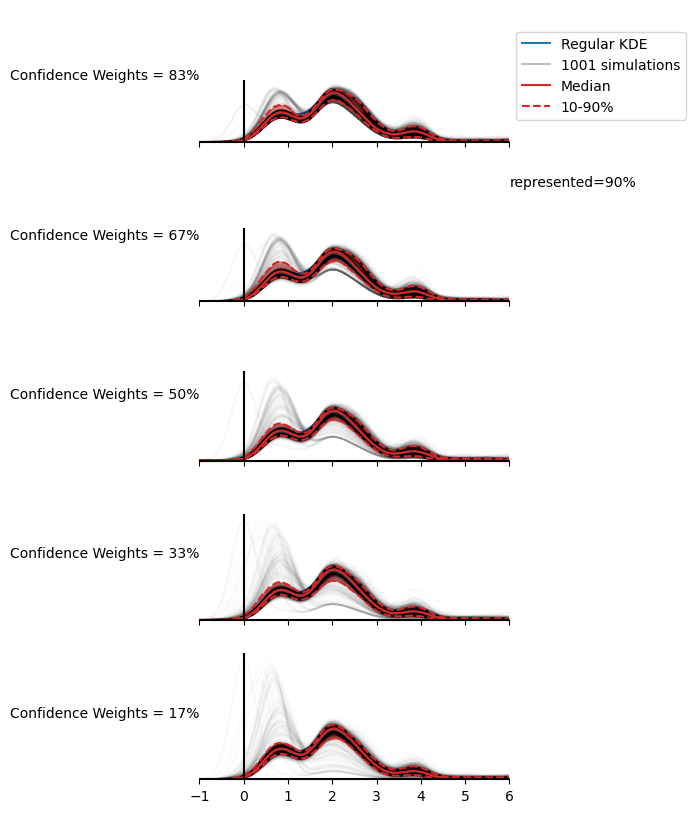

In [528]:
fig, axes = plt.subplots(len(options),1, sharex=True, sharey=True, figsize=(4,10))

for i, cw in enumerate(options):
    cw = cw[0]
    ax = axes[i]
    kde2_plot(totals[i], ax)
    ax.text(x=0, y=0.5, s=f'Confidence Weights = {int(np.round(cw,2)*100)}%', ha='right', va='center', transform=ax.transAxes)
    if i > 0:
        ax.legend().set_visible(False)
    ax.set_xlim(min(xvals), max(xvals))

ax = axes[1]
ax.text(x=1, y=0.9, s=f'represented={int(np.round(represented,2)*100)}%', ha='left', va='center', transform=ax.transAxes);

## target_means and target_tols

In [517]:
#different target_means and target_tols

data.sort()
totals = []
iqr = np.quantile(data,0.75) - np.quantile(data, 0.25)
bw = 0.9 * min([np.std(data), iqr/1.35]) * len(data)**-0.2
opt_means = [
    np.mean(data)*1.5,
    np.mean(data),
    np.mean(data)/2,
]

opt_tols = [
    np.std(data)*2,
    np.std(data),
    np.std(data)/2,
]

xvals = np.linspace(-1,10,1000)
    
for mean, tol in product(opt_means, opt_tols):
    total = kde2(data=data, target_mean=mean, target_tol=tol, xvals=xvals)[0]
    totals.append(total)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 236.34it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 295.58it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


...

FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 229.84it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 233.75it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 265.51it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

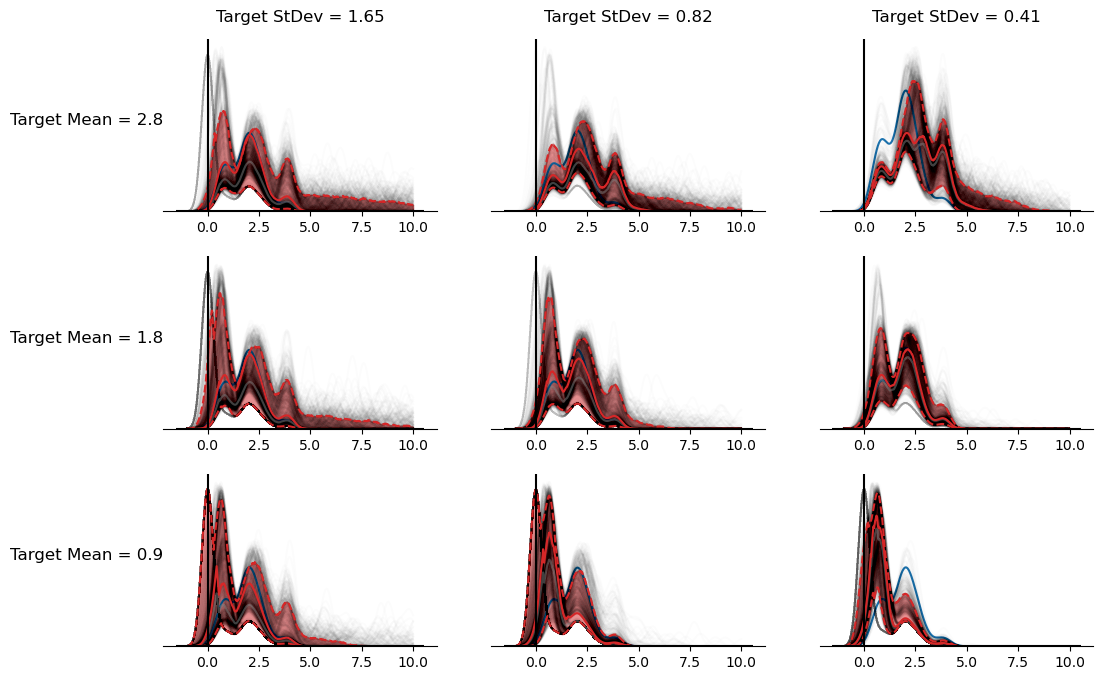

In [518]:
fig, axes = plt.subplots(3,3, figsize=(12,8))
i = 0
for r, c in product(np.arange(3), np.arange(3)):
    ax = axes[r,c]
    kde2_plot(totals[i], ax)
    ax.legend().set_visible(False)
    i += 1


fontsize = 12

for i, mean in enumerate(opt_means):
    axes[i,0].text(x=0,y=0.5, s=f'Target Mean = {np.round(mean,1)}', ha='right', va='center', fontsize=fontsize, transform=axes[i,0].transAxes)


for i, std in enumerate(opt_tols):
    axes[0,i].set_title(f'Target StDev = {np.round(std,2)}', ha='center', fontsize=fontsize)


# axes[0,0].text(x=-0.25,y=0.5, s='Target Mean 1.5x', ha='right', va='center', fontsize=fontsize, transform=axes[0,0].transAxes)
# axes[1,0].text(x=-0.25,y=0.5, s='Target Mean 1x', ha='right', va='center', fontsize=fontsize, transform=axes[1,0].transAxes)
# axes[2,0].text(x=-0.25,y=0.5, s='Target Mean 0.5x', ha='right', va='center', fontsize=fontsize, transform=axes[2,0].transAxes);


# ax.text(x=1, y=0.9, s=f'represented={int(np.round(adj,2)*100)}%', ha='left', va='center', transform=ax.transAxes);


## represented and confidence_weights

In [607]:
#different represented and confidence_weights

data.sort()
totals = []
iqr = np.quantile(data,0.75) - np.quantile(data, 0.25)
bw = 0.9 * min([np.std(data), iqr/1.35]) * len(data)**-0.2
opt_rep = [
    0.9,
    0.5,
    0.1,
]

opt_cw = [
    np.zeros_like(data) + 0.9,
    np.zeros_like(data) + 0.5,
    np.zeros_like(data) + 0.1,
]

xvals = np.linspace(-1,15,1000)
target_mean = np.mean(data)*2
    
for rep, cw in product(opt_rep, opt_cw):
    total = kde2(data=data, xvals=xvals, target_mean='auto', represented=rep, confidence_weights=cw)[0]
    totals.append(total)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 236.96it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 257.17it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


...

FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 241.91it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 263.82it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 249.51it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

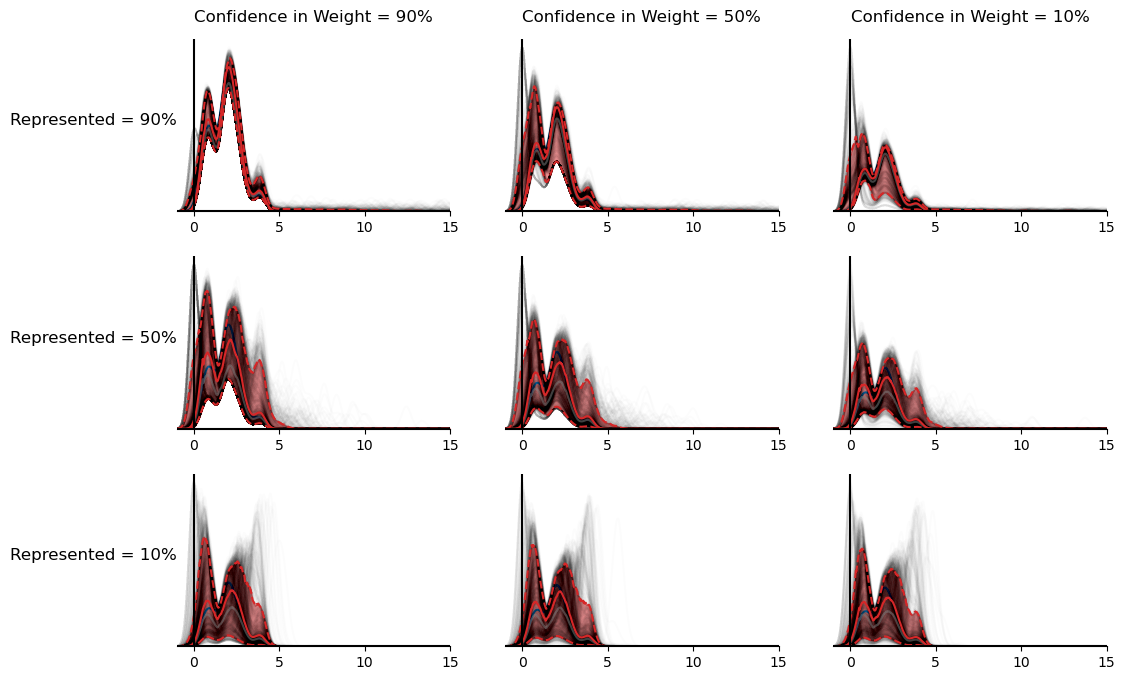

In [608]:
fig, axes = plt.subplots(3,3, figsize=(12,8))
i = 0
for r, c in product(np.arange(3), np.arange(3)):
    ax = axes[r,c]
    ax.set_xlim(min(xvals), max(xvals))
    kde2_plot(totals[i], ax)
    ax.legend().set_visible(False)
    i += 1


fontsize = 12

for i, rep in enumerate(opt_rep):
    axes[i,0].text(x=0,y=0.5, s=f'Represented = {int(np.round(rep,2)*100)}%', ha='right', va='center', fontsize=fontsize, transform=axes[i,0].transAxes)


for i, cw in enumerate(opt_cw):
    cw = cw[0]
    axes[0,i].set_title(f'Confidence in Weight = {int(np.round(cw,2)*100)}%', ha='center', fontsize=fontsize)

## represented

In [521]:
#different represented
data.sort()
totals = []
# options = [
#     0.9,
#     0.5,
#     0.1,
# ]
options = np.arange(0.1,1,0.1)
target_mean = np.mean(data)*2
xvals = np.linspace(-1,15,1000)

for rep in options:
    total = kde2(data=data, represented=rep, target_mean = target_mean, xvals=xvals)[0]
    totals.append(total)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 252.13it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 255.27it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.


...

FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 263.86it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 267.95it/s]


starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:03<00:00, 257.97it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

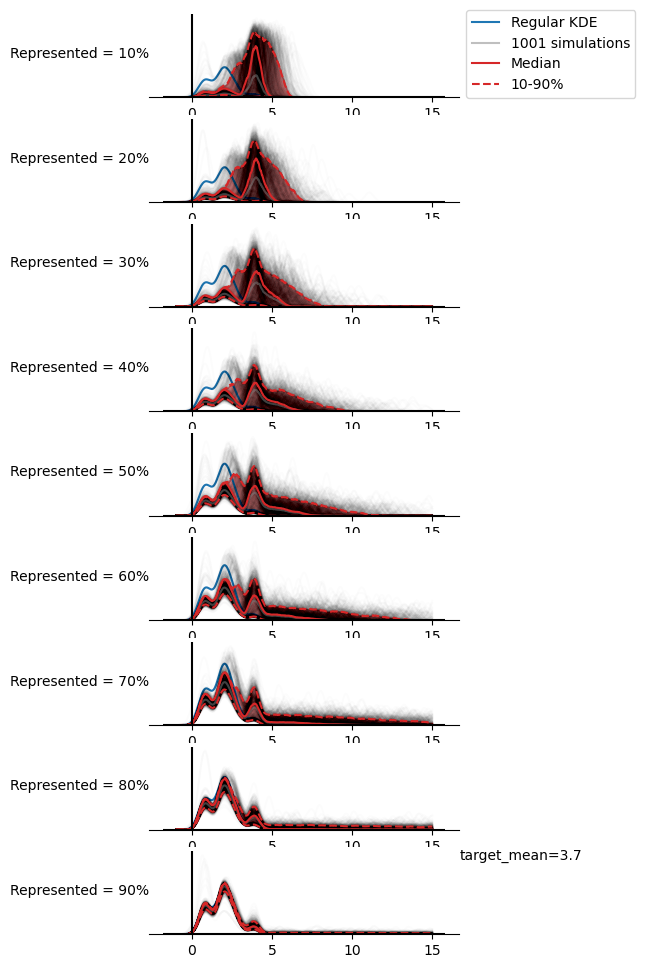

In [522]:
fig, axes = plt.subplots(len(options),1, figsize=(4,12))

for i, rep in enumerate(options):
    ax = axes[i]
    kde2_plot(totals[i], ax)
    ax.text(x=0, y=0.5, s=f'Represented = {int(np.round(rep,2)*100)}%', ha='right', va='center', transform=ax.transAxes)
    if i > 0:
        ax.legend().set_visible(False)

axes[1].text(x=1, y=0.9, s=f'target_mean={np.round(target_mean,1)}', ha='left', va='center', transform=ax.transAxes);


# Scratchpad

In [15]:
# def kde2(data,
#          xvals,
#          starting_weights='auto',
#          bandwidths='auto', 
#          confidence_weights='auto',
#          target_mean='auto',
#          target_tol='auto', 
#          represented='auto',
#          nruns=1001,
#         ):
xvals = np.linspace(-1,5,1000)
starting_weights='auto'
bandwidths='auto'
confidence_weights='auto'
target_mean='auto'
target_tol='auto'
represented='auto'
nruns=1001
"""
This function performs advanced KDE to a dataset, accommodating 
multiple sources of uncertainty and conveying a series of possible 
distributions as part of a Dirichlet Process.

INPUTS:
    data                All data points considered for this analysis in array-like format
    xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
    starting_weights    Weights for each point in "data". Values in this array are automatically normalized to sum to one.
    bandwidths          Bandwidths for each point in "data"
    confidence_weights  Confidence for each point in "data". The percentage of weight that remains unchanged
    target_mean         The desired mean of the overall distribution
    target_tol          The standard deviation of "target_mean"
    represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
    nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

OUTPUTS:
    totals              Array of (nruns * xvals) representing all resulting probability density functions
    dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
"""
####################################################################################
######################  CHECK INPUT DATA ###########################################
####################################################################################
data = np.array(data).flatten()
#check starting weights
if type(starting_weights) == str and starting_weights == 'auto':
    starting_weights = np.zeros_like(data) + 1/len(data)
    print('starting_weights has defaulted to uniform for all data points.')
else:
    starting_weights = check_array(starting_weights, data, 'starting_weights')
    starting_weights /= sum(starting_weights)

#check bandwidths
base_expval = sum(data*starting_weights)/sum(starting_weights)
base_std = np.sqrt(sum(starting_weights*(data-sum(data*starting_weights)/sum(starting_weights))**2)/sum(starting_weights))
cdf = starting_weights.copy()    
vals, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
vals, cdf = np.array(vals), np.array(cdf)
for i in range(len(cdf)-1):
    cdf[i+1] = cdf[i] + starting_weights[i]
cdf[0] = 0
cdf[-1] = 1
perc2val = sp.interpolate.interp1d(cdf, vals, assume_sorted=False) #got the quantile function for weighted values
iqr = perc2val(0.75)-perc2val(0.25)
base_bw = 0.9 * min([base_std, 1.35*iqr]) * len(data)**-0.2
if type(bandwidths) == str and bandwidths == 'auto':
    bandwidths = np.zeros_like(data) + base_bw
    print('bandwidths has defaulted to the Silverman method for all data points.')

else:
    bandwidths = check_array(bandwidths, data, 'bandwidths')

#check confidence_weights
if type(confidence_weights) == str and confidence_weights == 'auto':
    confidence_weights = np.zeros_like(data) + 0.5
    print(f'confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
else:
    confidence_weights = check_array(confidence_weights, data, 'confidence_weights')

#check target_mean
if type(target_mean) == str and target_mean == 'auto':
    target_mean = base_expval
    print(f'target_mean has defaulted to the weighted average of the dataset.')

#check target_tol
if type(target_tol) == str and target_tol == 'auto':
    target_tol = base_std
    print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

#check represented
if type(represented) == str and represented == 'auto':
    represented = 0.6
    print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
elif represented > 1 or represented < 0:
    raise ValueError("The variable 'represented' must be a value between 0 and 1")

#check xvals - must be an array of custom values
if len(xvals) == nruns:
    nruns += 1
    print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')


####################################################################################
######################  FUNCTION STARTS HERE #######################################
####################################################################################

#collect metadata
n = 10
all_weights = np.zeros(shape=(nruns,len(data)+n))
all_means = np.zeros(shape=(nruns,len(data)+n))
all_expval = np.zeros_like(range(nruns))
totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))
for i in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):
    # remove unrepresented data
    weights = starting_weights*represented
    bandwidths = bandwidths[:len(weights)]
    confidence_weights = confidence_weights[:len(weights)]

    # randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
    # means = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
    # while min(means) < 0:
    #     ind = np.where(means==min(means))[0][0]
    #     means[ind] = np.random.normal(data[ind], bandwidths)
    means = data

    # add new values to means to represent unrepresented data
    target = np.random.normal(target_mean, target_tol)
    while target < 0:
        target = np.random.normal(target_mean, target_tol)

    # pick where to add new values and what to assign them
    if target >= sum(means*weights)/sum(weights): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
        new_means = abs(np.random.normal(0,1,n))
        new_weights = np.random.beta(a=0.5, b=0.5, size=n)
        new_weights *= (1-represented)/sum(new_weights)
        new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
        factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
        new_means = target + new_means*factor
    elif target / (sum(means*weights)/sum(weights)) > represented: # target is less than expected value, but can still be reached with random values
        new_means = np.random.beta(a=0.5, b=0.5, size=n)
        new_weights = np.random.beta(a=0.5, b=0.5, size=n)
        new_weights *= (1-represented)/sum(new_weights)
        goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
        current_avg = sum(new_means*new_weights)/sum(new_weights)
        factor = goal_avg/current_avg
        new_means *= factor
    else: # positive values cannot help achieve our target, add big lump at zero
        new_means = np.array([0]*n)
        new_weights = np.array([1-represented]*n)

    weights = np.concatenate((weights, new_weights))
    means = np.concatenate((means, new_means))
    bandwidths = np.concatenate((bandwidths, np.zeros(len(new_means)) + base_bw))
    confidence_weights = np.concatenate((confidence_weights, np.zeros(len(new_means))))

    # separate into lower and higher than target. Preserve order of means and weights so they still match
    weights *= confidence_weights
    means_lo, weights_lo = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean < target]).T
    means_hi, weights_hi = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean >= target]).T

    #pare down existing weights according to our confidence
    leftover_weight = 1-sum(weights)

    # Get random values that will apply to the low and high means
    # rand_lo = np.random.beta(a=0.5, b=0.5, size=len(means_lo))
    # rand_hi = np.random.beta(a=0.5, b=0.5, size=len(means_hi))

    rand_lo = np.random.uniform(0,1,len(means_lo))
    rand_hi = np.random.uniform(0,1,len(means_hi))

    rand_lo *= leftover_weight/sum(rand_lo)
    rand_hi *= leftover_weight/sum(rand_hi)

    # find out weighted mean if all leftover_weight goes to low or if all goes to high
    lo = sum(means_lo*(rand_lo + weights_lo)) + sum(means_hi*weights_hi)
    hi = sum(means_hi*(rand_hi + weights_hi)) + sum(means_lo*weights_lo)

    # # find the proximity of the target relative to the weighted average of lower values. randomize according to target tolerance.
    prox_lo = (target-lo)/(hi-lo)
    if prox_lo < 0:
        prox_lo = 0
    elif prox_lo > 1:
        prox_lo = 1

    # # adjust weights according to our randomized proximity value
    weights_lo = weights_lo + rand_lo*(1-prox_lo)
    weights_hi = weights_hi + rand_hi*prox_lo

    # # put low and high weights and means back into the same array
    weights = np.concatenate((weights_lo, weights_hi))
    means = np.concatenate((means_lo, means_hi))

    all_weights[i] = weights
    all_means[i] = means
    all_expval[i] = sum(means*weights)/sum(weights)

    #evaluate all means
    yvals = norm.pdf(xvals.reshape(-1,1), means, bandwidths)*weights
    totals[i] = sum(yvals.T)
    totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

dict_analytics = {}
dict_analytics['all_means'] = all_means
dict_analytics['all_weights'] = all_means
dict_analytics['all_expval'] = all_expval


# return totals, dict_analytics

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:05<00:00, 195.85it/s]


In [85]:
yplot

array([0.07125055, 0.01085261, 0.10412746, 0.71073174, 0.10303764])

The Dirichlet distribution is a multivariate generalization of the Beta distribution. Importantly, the Dirichlet distribution samples from an N-dimensional simplex, which is an N-1 dimensional representation of the solution space for weights.

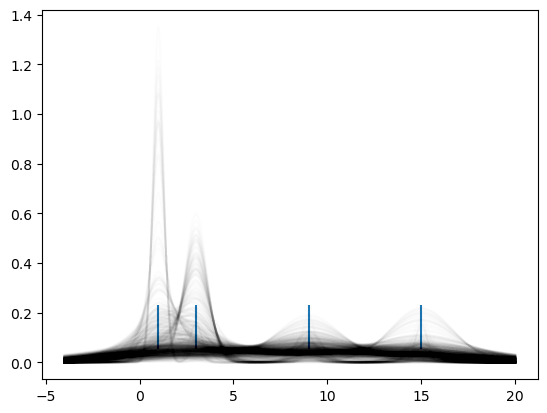

In [1392]:
vals = [1, 3, 9, 15]

fig, ax = plt.subplots()

xvals = np.linspace(-4,20,1_000)

for i in range(1_000):
    weights = np.random.uniform(0,1,len(vals))
    weights = np.random.beta(5, 5,len(vals))
    weights = np.random.dirichlet(np.ones(len(vals)))
    weights /= sum(weights)
    
    # get weighted bandwidth
    std = np.sqrt(sum(weights*(vals-sum(vals*weights)/sum(weights))**2)/sum(weights))
    cdf = weights.copy()    
    y_cdf, cdf = zip(*sorted(zip(np.append(vals, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
    y_cdf, cdf = np.array(y_cdf), np.array(cdf)
    for i in range(len(cdf)-1):
        cdf[i+1] = cdf[i] + weights[i]
    cdf[0] = 0
    cdf[-1] = 1
    perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
    iqr = perc2val(0.75)-perc2val(0.25)
    bw = 0.9 * min([std, iqr/1.35]) * len(vals)**-0.2
    
    #add up each kernel function
    yvals = np.zeros_like(xvals)
    for val, weight in zip(vals, weights):
        yvals += norm.pdf(xvals, val, bw)*weight
    
    ax.plot(xvals, yvals, alpha=0.01, color='black')
ax.scatter(vals, y=[ax.get_ylim()[1]*0.1]*len(vals), marker='|', s=1000)

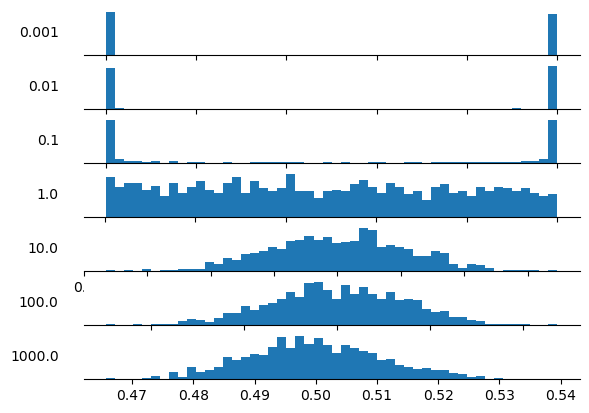

In [53]:
lst = np.arange(-3,4,1)

fig, axes = plt.subplots(len(lst),1)

for i, a in enumerate(lst):
    ax = axes[i]
    ax.hist(np.random.beta(10.**a, 10.**a, 1_000), bins=50)
    ax.text(x= -0.05, y=0.5, s=10.**a, ha='right', va='center', transform=ax.transAxes)
    ax.get_yaxis().set_visible(False)
    ax.spines[['top', 'right', 'left']].set_visible(False)

# Solving for the simplex space

In [8]:
%%time
import numpy as np
from scipy.linalg import null_space

def generate_feasible_samples(x, S, min_weights, group_constraints=None, num_samples=10_000, max_attempts=1_000_000):
    """
    INPUTS
    x                  input values
    min_weights        minimum weight for each sample
    group_constraints  a dictionary with sets of indices for "x", indicating which values should sum to a specific percentage
    num_samples        the desired number of samples
    max_attempts       how many attempts will be attempted, unless the number of valid samples is reached first
    
    OUTPUTS
    samples            an array of weights, size=(num_samples, len(x)), of sample weights, uniformly sampled from the simplex given all constraints
    
    Generates valid weights w such that:
    1. Each weight w_i has a minimum value min_weights[i]
    2. sum(w) = 1
    3. sum(w * x) = S
    4. sum of specific groups of weights = specified percentages
    5. w_i >= min_weights[i] for all i
    """

    N = len(x)

    # Check feasibility: S must be within the convex hull of x values
    S_min = np.sum(min_weights*x) + min(x)*(1-sum(min_weights))
    S_max = np.sum(min_weights*x) + max(x)*(1-sum(min_weights))
    if not (S_min <= S <= S_max):
        raise ValueError(f"S={S} is out of feasible range [{S_min}, {S_max}]")

    # Compute available weight budget after enforcing min_weights
    W_available = 1 - np.sum(min_weights)
    S_available = S - np.sum(min_weights * x)

    if W_available <= 0:
        raise ValueError("Minimum weights exceed total weight capacity.")

    # Create constraint matrix A_eq and right-hand side B
    A_eq = [np.ones(N)]  # First row ensures sum(v) = W_available
    B = [W_available]  # Right-hand side for sum(v) = W_available

    A_eq.append(x)  # Second row ensures sum(v * x) = S_available
    B.append(S_available)

    # Add group constraints
    if group_constraints != None:
        for indices, target_percent in group_constraints.items():
            group_constraint = np.zeros(N)
            for idx in indices:
                group_constraint[idx] = 1
            A_eq.append(group_constraint)
            B.append(target_percent-sum(min_weights[[indices]][0]))

    # Convert lists to numpy arrays
    A_eq = np.array(A_eq)
    B = np.array(B)

    # Compute null space of A_eq
    ns = null_space(A_eq)

    if ns.shape[1] != N - len(B):  # B has len(B) rows, so ns should have (N - len(B)) dimensions
        raise ValueError("Null space has incorrect dimension, check constraints.")

    # Compute a particular solution that satisfies the constraints
    v0 = np.linalg.pinv(A_eq) @ B  # Use pseudoinverse to get valid v0

    # Store valid samples
    samples = []
    attempt = 0
    while len(samples) < num_samples and attempt < max_attempts:
        attempt += 1

        # Step 1: Sample from the standard (N-2)-simplex
        z = np.random.normal(size=(N-len(B), 1))  # Use a Gaussian sample for coverage
        # z = np.random.exponential(size=(N-2, 1))
        # z = sample_uniform_simplex(N-2)  # Properly uniform sample
        # z = z.reshape(-1, 1)  

        # Step 2: Map to feasible space using null space transformation
        v = v0 + (ns @ z).flatten()

        # Step 3: Check non-negativity
        if np.all(v >= 0):
            w = min_weights + v.flatten()
            samples.append(w.flatten())
        # else:
        #     v = 
            
        # w = min_weights + v.flatten()
        # samples.append(w.flatten())

    print(f"{len(samples)}/{attempt} = {np.round(len(samples)/attempt*100,2)}%")
    # if len(samples) < num_samples:
    #     raise RuntimeError("Failed to generate enough valid samples within the maximum attempts.")

    return np.array(samples)

# Example usage
x = np.array([2, 5, 3, 7, 4])  # Values being weighted
x = np.random.uniform(1,10,7)  # Values being weighted
S = np.mean(x)  # Desired weighted sum
num_samples = 10_000  

# Minimum weight for each input value
min_weights = np.array([0.1, 0.05, 0.05, 0.1, 0.0])  # Must sum to ≤ 1
min_weights = np.ones(len(x))/len(x)/10

# Specify group constraints: sum of (w[0], w[2], w[3]) must be 60%
group_constraints = {
    (0, 2, 3): 0.6  # These indices must sum to 60% of the available weight
}

samples = generate_feasible_samples(x, S, min_weights, group_constraints, num_samples)


# Verify constraints
print("Sum of each weight vector:", np.round(np.sum(samples, axis=1)[:5], 5))  # Should be exactly 1
print("Weighted sum of each sample:", np.round(np.sum(samples * x, axis=1)[:5], 5))  # Should be exactly S
print("Any negative weights?", np.any(samples < 0))  # Should be False


241/1000000 = 0.02%
Sum of each weight vector: [1. 1. 1. 1. 1.]
Weighted sum of each sample: [6.597 6.597 6.597 6.597 6.597]
Any negative weights? False
CPU times: user 10.8 s, sys: 134 ms, total: 11 s
Wall time: 10.9 s


In [1385]:
S_available/W_available

4.7973178073052445

In [1389]:
v = np.random.dirichlet(np.ones(N))*W_available


In [1391]:
N = 7
sum(v*x)/sum(v)

6.025328542156559

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

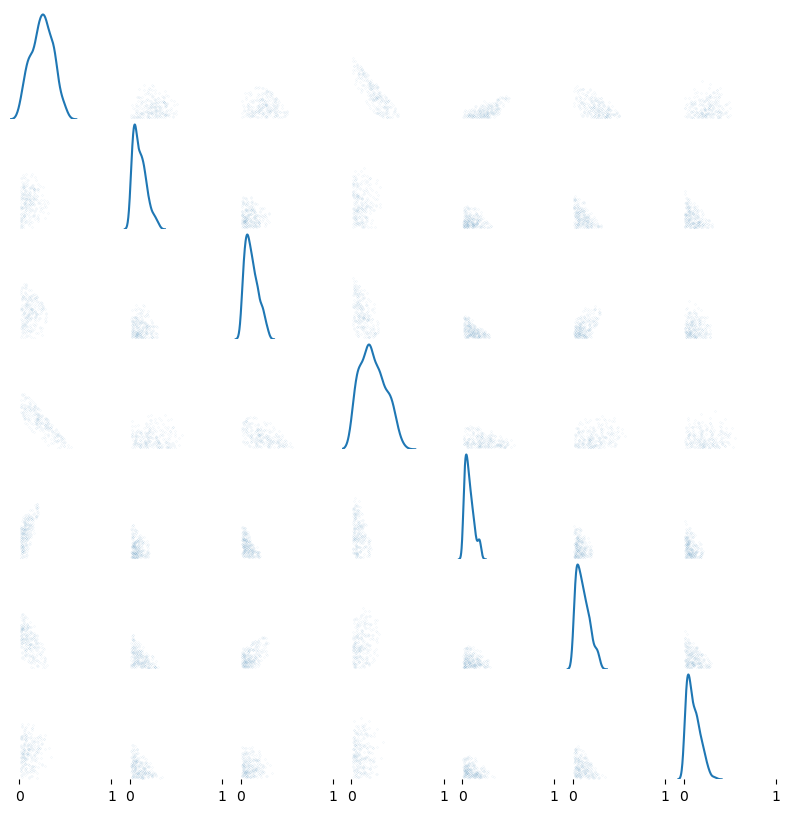

In [1380]:
results = np.array(samples).T
N = len(results)

fig, axes = plt.subplots(N, N, figsize=(10,10), sharex=True, gridspec_kw=dict(hspace=0, wspace=0))
for i, j in product(range(N), range(N)):
    ax = axes[i, j]
    if i == j:
        sns.kdeplot(results[i], ax=ax)
        ax.set_xlim(-0.1,1.1)
    else:
        ax.scatter(results[i], results[j], alpha=1, s=0.001)
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.get_yaxis().set_visible(False)


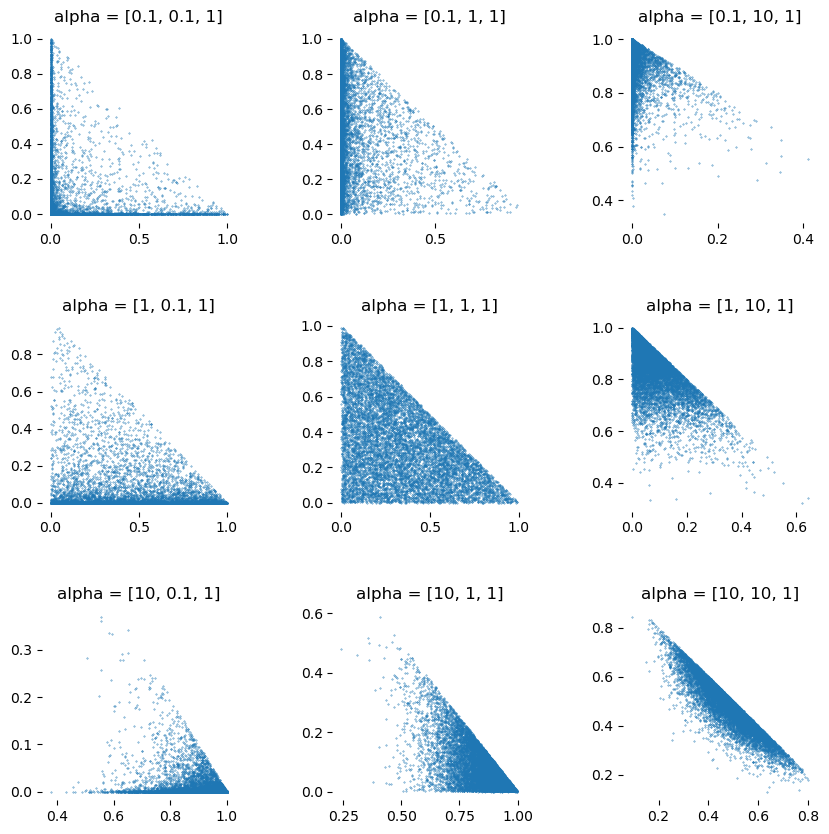

In [568]:
dim = 3
alphas = [0.1, 1, 10]

fig, axes = plt.subplots(len(alphas), len(alphas), figsize=(10,10), gridspec_kw=dict(hspace=0.5, wspace=0.5))

for (i, x), (j, y) in product(enumerate(alphas), enumerate(alphas)):
    ax = axes[i, j]
    alpha = [x, y, 1]
    results = np.random.dirichlet(alpha, 10_000)
    ax.scatter(results.T[0], results.T[1], alpha=1, s=0.1)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.set_title(f'alpha = {alpha}')
    
# xplot = results.T[0]
# yplot = results.T[1]

# fig, ax = plt.subplots()
# ax.scatter(xplot, yplot, alpha=0.1)

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.1

<Axes: ylabel='Density'>

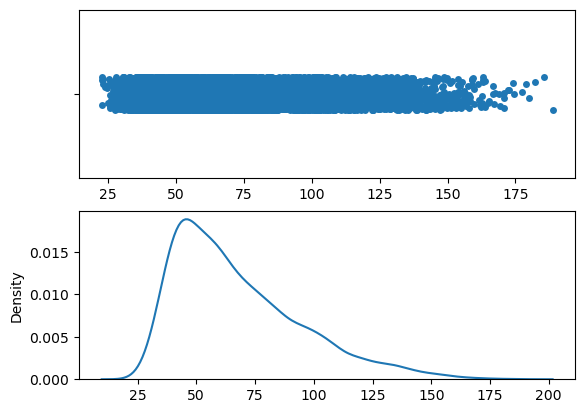

In [609]:
x = np.array([20, 50, 30, 200, 40])  # Values being weighted
n = 10_000

results = (np.random.dirichlet(np.ones(len(x)), n)*x).sum(axis=1)


fig, axes = plt.subplots(2,1)
ax = axes[0]
sns.stripplot(results, ax=ax, orient='h')

ax = axes[1]
sns.kdeplot(results, ax=ax)

In [ ]:
X = np.array([20, 50, 30, 200, 40])  # Values being weighted

target = 190
x = 20
np.setdiff1d(X,x)

#find lower bound
other_los = [ele for ele in np.setdiff1d(X,x) if ele < target]
other_his = [ele for ele in np.setdiff1d(X,x) if ele >= target]

if len(other_los) == 0: #this is the only value lower than the target
    lo = 1-sp.interpolate.interp1d([x,min(other_his)], [0,1])(target).flatten()[0]
    hi = 1-sp.interpolate.interp1d([x,max(other_his)], [0,1])(target).flatten()[0]
elif len(other_his) == 0: #this is the only value higher than the target
    lo = 1-sp.interpolate.interp1d([x,max(other_los)], [0,1])(target).flatten()[0]
    hi = 1-sp.interpolate.interp1d([x,min(other_los)], [0,1])(target).flatten()[0]
    
        
    


# DIY simplex solving

# Testing dirichlet process with shuffling

ok


In [883]:
%%time
means = np.array([150, 200, 300, 450])
n = 100_000

starting_weights = np.zeros_like(means) + 1.
starting_weights /= sum(starting_weights)
represented = 0.6
confidence_in_weights = np.zeros_like(means) + 0.7

weight_mins = starting_weights*confidence_in_weights*represented

samples = np.random.dirichlet(np.ones(len(mins)),n)

all_weights = []#np.zeros((n, len(means)))
movable_weight = 1-sum(weight_mins)

count = 0
for i, weights in enumerate(samples):
    weight = weight_mins + weights*movable_weight
    all_weights.append(weight)
    # if all(weight_mins < weights):
    #     count += 1
    #     all_weights.append(weights)

all_weights = np.array(all_weights)

CPU times: user 247 ms, sys: 18.8 ms, total: 266 ms
Wall time: 288 ms


In [913]:
(all_weights*means).sum(axis=1)

array([227.5051614 , 312.97857325, 277.50699839, ..., 301.64877935,
       235.54148818, 280.7116618 ])

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

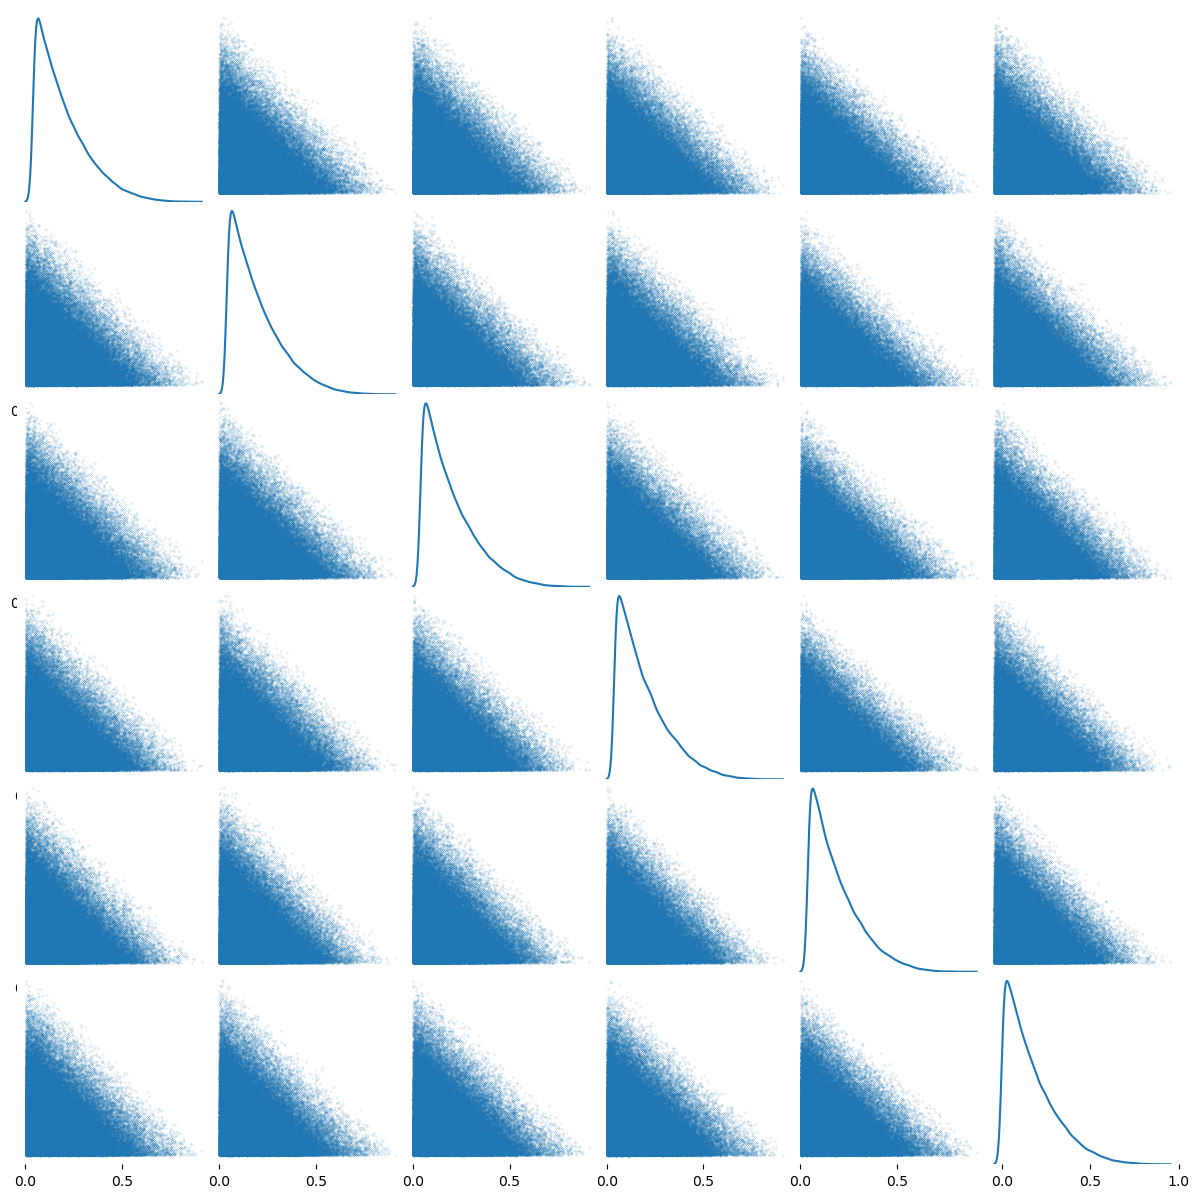

In [894]:
results = all_weights.T

N = len(results)

# fig, axes = plt.subplots(N, N, figsize=(15,15), sharex=True, gridspec_kw=dict(hspace=0, wspace=0))
fig, axes = plt.subplots(N, N, figsize=(15,15), gridspec_kw=dict(hspace=0, wspace=0))
for i, j in product(range(N), range(N)):
    ax = axes[i, j]
    if i == j:
        sns.kdeplot(results[i], ax=ax)
        # ax.set_xlim(-0.1,1.1)
    else:
        ax.scatter(results[i], results[j], alpha=1, s=0.01)
        # ax.set_xlim(0,1)
        # ax.set_ylim(0,1)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.get_yaxis().set_visible(False)


0.5800000000000001

# Simplex without rejection sampling

In [1315]:
import numpy as np
from scipy.optimize import linprog

def hit_and_run_sampling(x, S, min_weights, group_constraints, num_samples=1000, burn_in=500):
    """
    Uses Hit-and-Run Monte Carlo sampling to generate uniformly distributed weights that satisfy:
    - sum(w) = 1
    - sum(w * x) = S
    - group constraints
    - min_weights <= w_i (positivity)
    """

    N = len(x)
    
    # Initial feasible point
    min_weights = np.array(min_weights)
    W_available = 1 - np.sum(min_weights)
    S_available = S - np.sum(min_weights * x)

    if W_available <= 0:
        raise ValueError("Minimum weights exceed total capacity.")

    A_eq = [np.ones(N), x]
    B_eq = [W_available, S_available]

    for indices, target_percent in group_constraints.items():
        group_constraint = np.zeros(N)
        for idx in indices:
            group_constraint[idx] = 1
        A_eq.append(group_constraint)
        B_eq.append(target_percent-sum(min_weights[[indices]][0]))

    A_eq = np.array(A_eq)
    B_eq = np.array(B_eq)

    # Solve for an interior feasible point
    c = np.random.uniform(size=N)  # Random objective
    bounds = [(0, 1-min_w) for min_w in min_weights]
    res = linprog(c, A_eq=A_eq, b_eq=B_eq, bounds=bounds, method='highs')

    if not res.success:
        raise ValueError("Could not find an initial feasible solution.")

    w_current = res.x  # Start at feasible point
    
    # Compute a basis for the null space of A_eq
    _, _, Vt = np.linalg.svd(A_eq)
    null_space_basis = Vt[len(B_eq):].T  # Take the last rows corresponding to the null space
    
    # Hit-and-Run Sampling
    samples = []
    for _ in range(num_samples):
        max_retries = 50  # Allow multiple attempts to find a valid step
        found_valid_sample = False
        
        for _ in range(max_retries):
            # Sample a random direction in the null space
            z = np.random.randn(null_space_basis.shape[1])
            direction = null_space_basis @ z
            direction /= np.linalg.norm(direction)  # Normalize
            
            # Compute min and max step sizes
            max_step = np.inf
            min_step = -np.inf
            epsilon = 1e-8

            for i in range(N):
                if abs(direction[i]) > epsilon:
                    step_up = (1 - w0[i]) / direction[i]
                    step_down = (min_weights[i] - w0[i]) / direction[i]

                    if direction[i] > 0:
                        max_step = min(max_step, step_up)
                        min_step = max(min_step, step_down)
                    else:
                        max_step = min(max_step, step_down)
                        min_step = max(min_step, step_up)

            # Check if the step range is valid
            if min_step < max_step and not (np.isinf(max_step) or np.isinf(min_step)):
                step = np.random.uniform(min_step * 0.8, max_step * 0.8)
                w_sample = w0 + step * direction

                # Project any small numerical violations back into the feasible region
                w_sample = np.maximum(w_sample, min_weights)  # Enforce min weight
                w_sample /= np.sum(w_sample)  # Re-normalize to sum to 1

                # Validate the weighted sum condition
                if np.isclose(np.dot(w_sample, np.arange(1, N+1)), S, atol=1e-6):
                    samples.append(w_sample)
                    found_valid_sample = True
                    break  # Exit retry loop if valid sample is found

        if not found_valid_sample:
            raise ValueError("Failed to generate a valid sample after retries.")

        # Sample step size within a stable range
        step = np.random.uniform(min_step * 0.8, max_step * 0.8)  # Keep within range
        w_current += step * direction  # Move in sampled direction

        # Store sample after burn-in
        if iteration >= burn_in:
            samples.append(w_current.copy())

    return np.array(samples)

# Example usage
N = 100  # Number of values
x = np.random.uniform(1, 10, size=N)  # Random coefficients
S = 5  # Target weighted sum
num_samples = 500  

# Minimum weight for each input value
min_weights = np.random.uniform(0, 1/N, size=N)
min_weights *= 0.2/np.sum(min_weights)  # Normalize to sum < 1

# Example group constraints
group_constraints = {
    tuple(np.random.choice(N, size=10, replace=False)): 0.3,
    tuple(np.random.choice(N, size=15, replace=False)): 0.5
}

samples = hit_and_run_sampling(x, S, min_weights, group_constraints, num_samples)

# Check validity
print("Valid samples generated:", samples.shape)
print("Sum of weights (should be 1):", np.allclose(np.sum(samples, axis=1), 1))
print("Weighted sum (should be S):", np.allclose(np.sum(samples * x, axis=1), S))
print("All weights non-negative:", np.all(samples >= 0))


IndexError: index 5 is out of bounds for axis 0 with size 5

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/_q/2m7sk55j2hd11pdxzfgjpwz80000gn/T/ipykernel_49822/919397845.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(results[i], ax=ax)
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/_q/2m7sk55j2hd11pdxzfgjpwz80000gn/T/ipykernel_49822/919397845.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` 

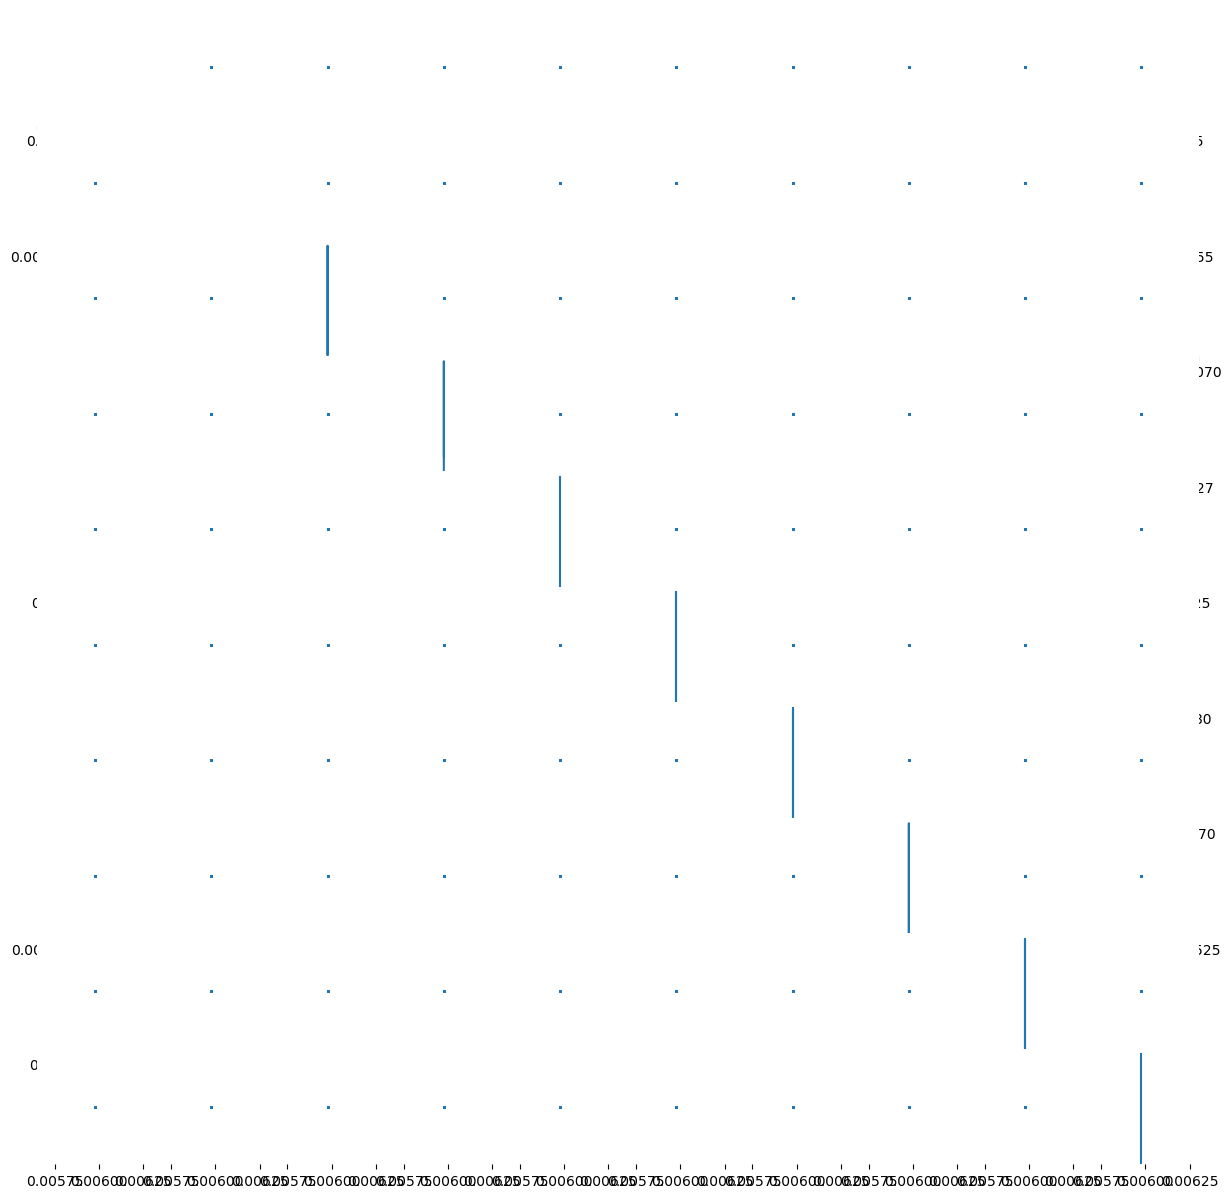

In [1289]:
results = samples.T[:10]

N = len(results)

# fig, axes = plt.subplots(N, N, figsize=(15,15), sharex=True, gridspec_kw=dict(hspace=0, wspace=0))
fig, axes = plt.subplots(N, N, figsize=(15,15), gridspec_kw=dict(hspace=0, wspace=0))
for i, j in product(range(N), range(N)):
    ax = axes[i, j]
    if i == j:
        sns.kdeplot(results[i], ax=ax)
        # ax.set_xlim(-0.1,1.1)
    else:
        ax.scatter(results[i], results[j], alpha=1, s=0.01)
        # ax.set_xlim(0,1)
        # ax.set_ylim(0,1)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.get_yaxis().set_visible(False)


In [1223]:
import numpy as np
from scipy.optimize import linprog

def sample_weights(x, S, min_weights, group_constraints, num_samples=1000):
    """
    Uniformly samples valid weight vectors w that satisfy:
    1. sum(w) = 1
    2. sum(w * x) = S
    3. w_i >= min_weights[i] for all i
    4. sum of specific groups of weights = specified percentages
    """

    N = len(x)
    
    # Ensure min_weights sum is feasible
    min_weights = np.array(min_weights)
    W_available = 1 - np.sum(min_weights)
    S_available = S - np.sum(min_weights * x)

    if W_available <= 0:
        raise ValueError("Minimum weights exceed total capacity.")

    # Equality constraints (sum-to-one, weighted sum, and group constraints)
    A_eq = [np.ones(N), x]  # sum(w) = 1 and sum(w * x) = S
    B_eq = [W_available, S_available]

    for indices, target_percent in group_constraints.items():
        group_constraint = np.zeros(N)
        for idx in indices:
            group_constraint[idx] = 1
        A_eq.append(group_constraint)
        B_eq.append(target_percent-sum(min_weights[[indices]][0]))

    A_eq = np.array(A_eq)
    B_eq = np.array(B_eq)

    # Solve for an interior feasible point
    c = np.random.uniform(size=N)  # Random objective
    bounds = [(min_w, None) for min_w in min_weights]
    res = linprog(c, A_eq=A_eq, b_eq=B_eq, bounds=bounds, method='highs')

    if not res.success:
        raise ValueError("Could not find an initial feasible solution.")

    w0 = res.x  # Feasible interior point

    # Construct sampling matrix from feasible region
    Q, _ = np.linalg.qr(np.random.randn(N, N))  # Random rotation matrix

    samples = []
    for _ in range(num_samples):
        # Sample from a Dirichlet distribution
        z = np.random.dirichlet(np.ones(N))

        # Transform into constraint-satisfying space
        w = w0 + Q @ (z - np.mean(z))
        w += min_weights

        # Ensure positivity
        # if np.all(w >= min_weights) and np.allclose(A_eq @ w, B_eq):
        #     samples.append(w)
        samples.append(w)

    return np.array(samples)

# Example usage
N = 100  # Number of values
x = np.random.uniform(1, 10, size=N)  # Random coefficients
S = 5  # Target weighted sum
num_samples = 500  

# Minimum weight for each input value
min_weights = np.random.uniform(0.005, 0.02, size=N)
min_weights *= 0.2/np.sum(min_weights)  # Normalize to sum < 1

# Example group constraints
group_constraints = {
    tuple(np.random.choice(N, size=10, replace=False)): 0.3,
    tuple(np.random.choice(N, size=15, replace=False)): 0.5
}

samples = sample_weights(x, S, min_weights, group_constraints, num_samples)

# Check validity
print("Valid samples generated:", samples.shape)
print("Sum of weights (should be 1):", np.allclose(np.sum(samples, axis=1), 1))
print("Weighted sum (should be S):", np.allclose(np.sum(samples * x, axis=1), S))
print("All weights non-negative:", np.all(samples >= 0))


Valid samples generated: (500, 100)
Sum of weights (should be 1): False
Weighted sum (should be S): False
All weights non-negative: False


<Axes: >

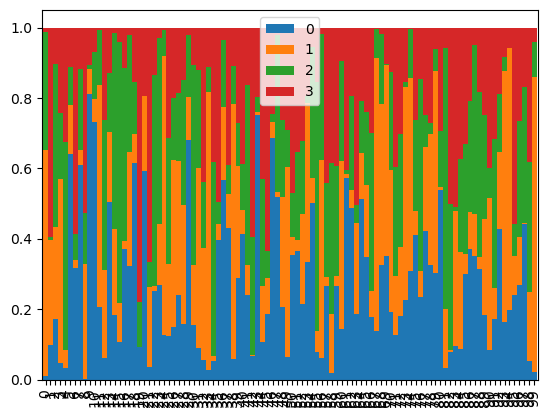

In [1449]:
# fig, ax = plt.subplots()
data0 =np.random.dirichlet([1,1,1,1],100)
df = pd.DataFrame(data0)
# df['ind'] = df.index

df.plot(kind='bar', stacked=True, width=1)

# Dirichlet with grouping

In [1532]:
starting_weights='auto'
bandwidths='auto'
confidence_weights='auto'
target_mean='auto'
target_tol='auto'
represented='auto'
nruns=1001
"""
This function performs advanced KDE to a dataset, accommodating 
multiple sources of uncertainty and conveying a series of possible 
distributions as part of a Dirichlet Process.

INPUTS:
    data                All data points considered for this analysis in array-like format
    xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
    starting_weights    Weights for each point in "data". Values in this array are automatically normalized to sum to one.
    bandwidths          Bandwidths for each point in "data"
    confidence_weights  Confidence for each point in "data". The percentage of weight that remains unchanged
    target_mean         The desired mean of the overall distribution
    target_tol          The standard deviation of "target_mean"
    represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
    nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

OUTPUTS:
    totals              Array of (nruns * xvals) representing all resulting probability density functions
    dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
"""
####################################################################################
######################  CHECK INPUT DATA ###########################################
####################################################################################
data = np.array(data).flatten()
lst1 = []
lst2 = []
#check starting weights
if type(starting_weights) == str and starting_weights == 'auto':
    starting_weights = np.zeros_like(data) + 1/len(data)
    print('starting_weights has defaulted to uniform for all data points.')
else:
    starting_weights = check_array(starting_weights, data, 'starting_weights')
    starting_weights /= sum(starting_weights)

#check bandwidths
base_expval = sum(data*starting_weights)/sum(starting_weights)
base_std = np.sqrt(sum(starting_weights*(data-sum(data*starting_weights)/sum(starting_weights))**2)/sum(starting_weights))
cdf = starting_weights.copy()    
y_cdf, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
y_cdf, cdf = np.array(y_cdf), np.array(cdf)
for i in range(len(cdf)-1):
    cdf[i+1] = cdf[i] + starting_weights[i]
cdf[0] = 0
cdf[-1] = 1
perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
iqr = perc2val(0.75)-perc2val(0.25)
base_bw = 0.9 * min([base_std, iqr/1.35]) * len(data)**-0.2
if type(bandwidths) == str and bandwidths == 'auto':
    bandwidths = np.zeros_like(data) + base_bw
    print('bandwidths has defaulted to the Silverman method for all data points.')

else:
    bandwidths = check_array(bandwidths, data, 'bandwidths')

#check confidence_weights
if type(confidence_weights) == str and confidence_weights == 'auto':
    confidence_weights = np.zeros_like(data) + 0.5
    print(f'confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
else:
    confidence_weights = check_array(confidence_weights, data, 'confidence_weights')

#check target_mean
if type(target_mean) == str and target_mean == 'auto':
    target_mean = base_expval
    print(f'target_mean has defaulted to the weighted average of the dataset.')

#check target_tol
if type(target_tol) == str and target_tol == 'auto':
    target_tol = base_std
    print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

#check represented
if type(represented) == str and represented == 'auto':
    represented = 0.6
    print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
elif represented > 1 or represented < 0:
    raise ValueError("The variable 'represented' must be a value between 0 and 1")

#check xvals - must be an array of custom values
if len(xvals) == nruns:
    nruns += 1
    print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')


####################################################################################
######################  FUNCTION STARTS HERE #######################################
####################################################################################

#collect metadata
n = 10
all_weights = np.zeros(shape=(nruns,len(data)+n))
all_means = np.zeros(shape=(nruns,len(data)+n))
all_expval = np.zeros_like(range(nruns))
totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))


# for i in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):


i = 0
# remove unrepresented data
weights = starting_weights*represented
bandwidths = bandwidths[:len(weights)]
confidence_weights = confidence_weights[:len(weights)]

# randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
# means = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
# while min(means) < 0:
#     ind = np.where(means==min(means))[0][0]
#     means[ind] = np.random.normal(data[ind], bandwidths)
means = data

# add new values to means to represent unrepresented data
target = np.random.normal(target_mean, target_tol)
while target < 0:
    target = np.random.normal(target_mean, target_tol)

# pick where to add new values and what to assign them
if target >= sum(means*weights)/sum(weights): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
    new_means = abs(np.random.normal(0,1,n))
    new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
    new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
    factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
    new_means = target + new_means*factor
elif target / (sum(means*weights)/sum(weights)) > represented: # target is less than expected value, but can still be reached with random values
    new_means = np.random.uniform(0, 1, size=n)
    new_weights = np.random.dirichlet(np.ones(n),1)[0]*(1-represented)
    goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
    current_avg = sum(new_means*new_weights)/sum(new_weights)
    factor = goal_avg/current_avg
    new_means *= factor
else: # positive values cannot help achieve our target, add big lump at zero
    new_means = np.array([0]*n)
    new_weights = np.array([(1-represented)/n]*n)

weights = np.concatenate((weights, new_weights))
means = np.concatenate((means, new_means))
bandwidths = np.concatenate((bandwidths, np.zeros(len(new_means)) + base_bw))
confidence_weights = np.concatenate((confidence_weights, np.zeros(len(new_means))))

# separate into lower and higher than target. Preserve order of means and weights so they still match
weights *= confidence_weights
# means_lo, weights_lo = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean < target]).T
# means_hi, weights_hi = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean >= target]).T

weights

#pare down existing weights according to our confidence
# leftover_weight = 1-sum(weights)

# # Get random values that will apply to the low and high means
# # rand_lo = np.random.beta(a=0.5, b=0.5, size=len(means_lo))
# # rand_hi = np.random.beta(a=0.5, b=0.5, size=len(means_hi))

# rand_lo = np.random.dirichlet(np.ones(len(means_lo)),1)[0]*leftover_weight
# rand_hi = np.random.dirichlet(np.ones(len(means_hi)),1)[0]*leftover_weight

# # find out weighted mean if all leftover_weight goes to low or if all goes to high
# lo = sum(means_lo*(rand_lo + weights_lo)) + sum(means_hi*weights_hi)
# hi = sum(means_hi*(rand_hi + weights_hi)) + sum(means_lo*weights_lo)

# # # find the proximity of the target relative to the weighted average of lower values. randomize according to target tolerance.
# prox_lo = (target-lo)/(hi-lo)
# if prox_lo < 0:
#     prox_lo = 0
# elif prox_lo > 1:
#     prox_lo = 1

# lst1.append(prox_lo)
# # # adjust weights according to our randomized proximity value
# weights_lo = weights_lo + rand_lo*(1-prox_lo)
# weights_hi = weights_hi + rand_hi*prox_lo

# # # put low and high weights and means back into the same array
# weights = np.concatenate((weights_lo, weights_hi))
# means = np.concatenate((means_lo, means_hi))

# all_weights[i] = weights
# all_means[i] = means
# all_expval[i] = sum(means*weights)/sum(weights)

# #evaluate all means
# yvals = norm.pdf(xvals.reshape(-1,1), means, bandwidths)*weights
# totals[i] = sum(yvals.T)
# totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

starting_weights has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
confidence_weights has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_mean has defaulted to the weighted average of the dataset.
target_tol has defaulted to the weighted standard deviation of the dataset.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


array([0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.003, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   ])

In [2092]:
X = np.random.uniform(0,10,150)

In [2112]:
%%time
#single grouping function
#initialize data
target = 5
target_remaining = target-sum(means*weights)
group_constraints = {
    (0,2,4,6,8): 0.1,
    (12,15,18,21): 0.15,
    (24,28,32,36): 0.25,
}

# group_constraints = {
#     tuple(np.arange(len(means))): 1
# }
    


#add remaining indices to group_constraints as additional group so all indices are accounted for
ind_remainder = list(np.arange(len(X)))
perc_remainder = 1
for group, perc in group_constraints.items():
    for ind in group:
        if ind not in ind_remainder:
            raise ValueError(f'The index {ind} is either referenced twice or lies outside the bounds for dataset of length {len(means)}')
        ind_remainder.remove(ind)
    perc_remainder -= perc

if perc_remainder < 0:
    raise ValueError('group_constraints inputs total greater than 1')
elif len(ind_remainder) == 0 or perc_remainder == 0:
    pass
else:
    group_constraints[tuple(ind_remainder)] = perc_remainder

    
    
W_base = 'auto'
W_confidence = np.zeros_like(X) + 0.5
represented = 0.6
if type(W_base) == str and W_base == 'auto':
    W_base = np.zeros_like(X)
    for group, perc in group_constraints.items():
        for ind in group:
            W_base[ind] = perc/len(group)
    print('W_base has defaulted to uniform for all data points.')
else:
    for group, perc in group_constraints.items():
        if sum(W_base[list(group)]) > perc:
            raise ValueError(f'W_base is incompatible with group_constraints. Group sum = {sum(W_base[list(group)])}, group_constraint = {perc} for group {group}')
    W_base = check_array(W_base, data, 'W_base')
    W_base /= sum(W_base)

W_base has defaulted to uniform for all data points.
CPU times: user 611 μs, sys: 977 μs, total: 1.59 ms
Wall time: 1.14 ms


In [2129]:
W = W_base*W_confidence

# reduce group constraints to accommodate additional weight
group_constraints_reduced = group_constraints.copy()
for group in group_constraints.keys():
    for ind in group:
        group_constraints_reduced[group] -= W[ind]

# randomize weights and prepare targets
group_evs = [] #expected values for each group given randomized dirichlet weights
ws_rand = []
for group, perc in group_constraints.items():
    w = np.random.dirichlet(np.ones(len(group)))*perc
    ws_rand.append(w)
    group_evs.append(sum(X[list(group)]*w))

group_evs_target = [ele/sum(group_evs)*target_remaining for ele in group_evs] # target values, proportional to expected values

# get weights that reach our target S_remaining
ws_soln = ws_rand.copy()
for i, group in enumerate(group_constraints_reduced):
    x_cutoff = group_evs_target[i]/sum(ws_rand[i])

    if x_cutoff < min(means[list(group)]) or x_cutoff > max(means[list(group)]):
        break

    xlo, wlo, jlo = np.array([(x, w, j) for (x, w, j) in zip(X[list(group)], ws_rand[i], np.arange(len(ws_rand[i]))) if x < x_cutoff]).T
    xhi, whi, jhi = np.array([(x, w, j) for (x, w, j) in zip(X[list(group)], ws_rand[i], np.arange(len(ws_rand[i]))) if x >= x_cutoff]).T

    proxlo_target = sp.interpolate.interp1d([sum(xlo*wlo)/sum(wlo), sum(xhi*whi)/sum(whi)],[0,1])(x_cutoff).flatten()[0]
    proxlo_current = sum(whi)/(sum(wlo)+sum(whi))

    hi_change = proxlo_target/proxlo_current
    lo_change = (1+(sum(whi)-sum(whi*hi_change))/sum(wlo))

    ws_unordered = np.concatenate((wlo*lo_change, whi*hi_change))
    order = list(np.concatenate((jlo, jhi)).astype(int))
    ws_ordered = ws_unordered.copy()
    for it, o in enumerate(order):
        ws_ordered[o] = ws_unordered[it]
    ws_soln[i] = ws_ordered

#verification that target was reached
if x_cutoff < min(means[list(group)]) or x_cutoff > max(means[list(group)]):
    pass
else:
    lst = []
    for i, group in enumerate(group_constraints_reduced):
        total = sum(means[list(group)]*ws_soln[i])
        if np.round(total/group_evs_target[i],5) != 1:
            raise ValueError('Target was not reached')

In [2339]:
def kde2(data,
         xvals,
         group_constraints='auto',
         W_base='auto',
         bandwidths='auto', 
         W_confidence='auto',
         target_mean='auto',
         target_tol='auto', 
         represented='auto',
         nruns=1001,
        ):
    # group_constraints='auto',
    # W_base='auto'
    # bandwidths='auto'
    # W_confidence='auto'
    # target_mean='auto'
    # target_tol='auto'
    # represented='auto'
    # nruns=1001
    """
    This function performs advanced KDE to a dataset, accommodating 
    multiple sources of uncertainty and conveying a series of possible 
    distributions as part of a Dirichlet Process.

    INPUTS:
        data                All data points considered for this analysis in array-like format
        xvals               This must be a user input so you know how to plot the resulting totals. Use np.linspace(start, stop, num)
        W_base              Weights for each point in "data". Values in this array are automatically normalized to sum to one.
        bandwidths          Bandwidths for each point in "data"
        W_confidence        Confidence for each point in "data". The percentage of weight that remains unchanged
        target_mean         The desired mean of the overall distribution
        target_tol          The standard deviation of "target_mean"
        represented         What percentage of the overall data is represented by this dataset. Weight represented by new, random values
        nruns=1000          How many probability density functions are produced. Recommended minimum 1000, which is the autofill value

    OUTPUTS:
        totals              Array of (nruns * xvals) representing all resulting probability density functions
        dict_analytics      Dictionary of some results, including all_means, all_weights, and all_expval
    """
    ####################################################################################
    ######################  CHECK INPUT DATA ###########################################
    ####################################################################################
    X = np.array(data).flatten()
    lst1 = []
    lst2 = []

    #check group_constraints
    if type(group_constraints) == str and group_constraints == 'auto':
        group_constraints = {
            tuple(np.arange(len(X))): 1,
        }
        print('No group constraints were provided')
    else:
    #add remaining indices to group_constraints as additional group so all indices are accounted for
        ind_remainder = list(np.arange(len(X)))
        perc_remainder = 1
        for group, perc in group_constraints.items():
            for ind in group:
                if ind not in ind_remainder:
                    raise ValueError(f'The index {ind} is either referenced twice or lies outside the bounds for dataset of length {len(means)}')
                ind_remainder.remove(ind)
            perc_remainder -= perc

        if perc_remainder < 0:
            raise ValueError('group_constraints inputs total greater than 1')
        elif len(ind_remainder) == 0 or perc_remainder == 0:
            pass
        else:
            group_constraints[tuple(ind_remainder)] = perc_remainder

    #check W_base
    if type(W_base) == str and W_base == 'auto':
        W_base = np.zeros_like(X)
        for group, perc in group_constraints.items():
            for ind in group:
                W_base[ind] = perc/len(group)
        print('W_base has defaulted to uniform for all data points.')
    else:
        for group, perc in group_constraints.items():
            if sum(W_base[list(group)]) > perc:
                raise ValueError(f'W_base is incompatible with group_constraints. Group sum = {sum(W_base[list(group)])}, group_constraint = {perc} for group {group}')
        W_base = check_array(W_base, data, 'W_base')
        W_base /= sum(W_base)

    #check bandwidths
    base_expval = sum(data*W_base)/sum(W_base)
    base_std = np.sqrt(sum(W_base*(data-sum(data*W_base)/sum(W_base))**2)/sum(W_base))
    cdf = W_base.copy()    
    y_cdf, cdf = zip(*sorted(zip(np.append(data, [0]), np.append(cdf, [0])), key=lambda x: x[0]))
    y_cdf, cdf = np.array(y_cdf), np.array(cdf)
    for i in range(len(cdf)-1):
        cdf[i+1] = cdf[i] + W_base[i]
    cdf[0] = 0
    cdf[-1] = 1
    perc2val = sp.interpolate.interp1d(cdf, y_cdf, assume_sorted=False) #got the quantile function for weighted values
    iqr = perc2val(0.75)-perc2val(0.25)
    base_bw = 0.9 * min([base_std, iqr/1.35]) * len(data)**-0.2
    if type(bandwidths) == str and bandwidths == 'auto':
        bandwidths = np.zeros_like(data) + base_bw
        print('bandwidths has defaulted to the Silverman method for all data points.')

    else:
        bandwidths = check_array(bandwidths, data, 'bandwidths')

    #check W_confidence
    if type(W_confidence) == str and W_confidence == 'auto':
        W_confidence = np.zeros_like(data) + 0.5
        print(f'W_confidence has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.')
    else:
        W_confidence = check_array(W_confidence, data, 'W_confidence')

    #check target_mean
    if type(target_mean) == str and target_mean == 'auto':
        target_mean = base_expval
        print(f'target_mean has defaulted to the weighted average of the dataset.')

    #check target_tol
    if type(target_tol) == str and target_tol == 'auto':
        target_tol = base_std
        print(f'target_tol has defaulted to the weighted standard deviation of the dataset.')

    #check represented
    if type(represented) == str and represented == 'auto':
        represented = 0.6
        print('represented has defaulted to 0.6, indicating that this dataset represents 60% of all values')
    elif represented > 1 or represented < 0:
        raise ValueError("The variable 'represented' must be a value between 0 and 1")

    #check xvals - must be an array of custom values
    if len(xvals) == nruns:
        nruns += 1
        print('nruns has been increased by 1 to avoid being the same integer as xvals. This is to avoid confusing dimensions of the reuslts.')



    ####################################################################################
    ######################  FUNCTION STARTS HERE #######################################
    ####################################################################################

    #collect metadata
    n_added = 10
    W_all = np.zeros(shape=(nruns,len(data)+n_added))
    X_all = np.zeros(shape=(nruns,len(data)+n_added))
    EV_all = np.zeros_like(range(nruns))
    totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))
    for run in tqdm(range(nruns), desc='FOR LOOP PROGRESS'):
        # remove unrepresented data
        W = W_base*represented
        bandwidths = bandwidths[:len(W)]
        W_confidence = W_confidence[:len(W)]

        # randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
        # X = np.random.normal(data, bandwidths) #random value with each ECC as the mean and bandwidth
        # while min(X) < 0:
        #     ind = np.where(X==min(X))[0][0]
        #     X[ind] = np.random.normal(data[ind], bandwidths)
        X = data

        # add new values to X to represent unrepresented data
        target = np.random.normal(target_mean, target_tol)
        while target < 0:
            target = np.random.normal(target_mean, target_tol)

        # pick where to add new values and what to assign them
        if target >= sum(X*W)/sum(W): #if the target is greater than the expected value, they represent a half-normal (positive) distribution
            xnew = abs(np.random.normal(0,1,n_added))
            wnew = np.random.dirichlet(np.ones(n_added),1)[0]*(1-represented)
            xnew /= sum(xnew*wnew)/sum(wnew) #normalize so weighted average is 1
            factor = (target-sum(X*W)/sum(W))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
            xnew = target + xnew*factor
        elif target / (sum(X*W)/sum(W)) > represented: # target is less than expected value, but can still be reached with random values
            xnew = np.random.uniform(0, 1, size=n_added)
            wnew = np.random.dirichlet(np.ones(n_added),1)[0]*(1-represented)
            goal_avg = -(((sum(X*W)/sum(W)-target)*represented) / (1-represented) - target)
            current_avg = sum(xnew*wnew)/sum(wnew)
            factor = goal_avg/current_avg
            xnew *= factor
        else: # positive values cannot help achieve our target, add big lump at zero
            xnew = np.array([0]*n)
            wnew = np.array([(1-represented)/n]*n)

        W = np.concatenate((W, wnew))
        X = np.concatenate((X, xnew))
        bandwidths = np.concatenate((bandwidths, np.zeros(len(xnew)) + base_bw))
        W_confidence = np.concatenate((W_confidence, np.zeros(len(xnew))))

        #now that we have all values in X, let's make sure we hit our grouping targets
        W *= W_confidence
        target_remaining = target-sum(X*W)


        #make room in group_constraints for additional values
        group_constraints_reduced = group_constraints.copy()
        for group, perc in group_constraints_reduced.items():
            group_constraints_reduced[group] *= represented
        group_constraints_reduced[tuple(np.arange(len(X)-n_added, len(X),1))] = 1-represented

        # reduce group constraints to accommodate additional weight
        for group in group_constraints.keys():
            for ind in group:
                group_constraints_reduced[group] -= W[ind]

        # randomize weights and prepare targets
        group_evs = [] #expected values for each group given randomized dirichlet weights
        ws_rand = []
        for group, perc in group_constraints_reduced.items():
            w = np.random.dirichlet(np.ones(len(group)))*perc
            ws_rand.append(w)
            group_evs.append(sum(X[list(group)]*w))

        group_evs_target = [ele/sum(group_evs)*target_remaining for ele in group_evs] # target values, proportional to expected values

        # get weights that reach our target S_remaining
        ws_soln = ws_rand.copy()
        for i, group in enumerate(group_constraints_reduced):
            x_cutoff = group_evs_target[i]/sum(ws_rand[i])

            if x_cutoff < min(X[list(group)]) or x_cutoff >= max(X[list(group)]):
                break

            xlo, wlo, jlo = np.array([(x, w, j) for (x, w, j) in zip(X[list(group)], ws_rand[i], np.arange(len(ws_rand[i]))) if x < x_cutoff]).T
            xhi, whi, jhi = np.array([(x, w, j) for (x, w, j) in zip(X[list(group)], ws_rand[i], np.arange(len(ws_rand[i]))) if x >= x_cutoff]).T

            proxlo_target = sp.interpolate.interp1d([sum(xlo*wlo)/sum(wlo), sum(xhi*whi)/sum(whi)],[0,1])(x_cutoff).flatten()[0]
            proxlo_current = sum(whi)/(sum(wlo)+sum(whi))

            hi_change = proxlo_target/proxlo_current
            lo_change = (1+(sum(whi)-sum(whi*hi_change))/sum(wlo))

            ws_unordered = np.concatenate((wlo*lo_change, whi*hi_change))
            order = list(np.concatenate((jlo, jhi)).astype(int))
            ws_ordered = ws_unordered.copy()
            for it, o in enumerate(order):
                ws_ordered[o] = ws_unordered[it]
            ws_soln[i] = ws_ordered

        #verification that target was reached
        # if x_cutoff < min(X[list(group)]) or x_cutoff > max(X[list(group)]):
        #     pass
        # else:
        #     for i, group in enumerate(group_constraints_reduced):
        #         total = sum(X[list(group)]*ws_soln[i])
        #         if np.round(total/group_evs_target[i],5) != 1:
        #             raise ValueError('Target was not reached')

        # add all the final weights to W
        for i_group, group in enumerate(group_constraints_reduced):
            for i_source, i_target in enumerate(group):
                W[i_target] += ws_soln[i_group][i_source]


        W_all[run] = W
        X_all[run] = X
        EV_all[run] = sum(X*W)/sum(W)

        #evaluate all X's
        yvals = norm.pdf(xvals.reshape(-1,1), X, bandwidths)*W
        totals[run] = sum(yvals.T)
        totals[run] /= sp.integrate.trapezoid(totals[run], xvals)

    dict_analytics = {}
    dict_analytics['all_values'] = X_all
    dict_analytics['all_weights'] = W_all
    dict_analytics['all_expval'] = EV_all
    if len(lst1) > 0:
        dict_analytics['lst1'] = lst1
    if len(lst2) > 0:
        dict_analytics['lst2'] = lst2


    return totals, dict_analytics

In [2364]:
data = np.random.uniform(1,10,10_000)
xvals = np.linspace(-5,30,1000)

# group_constraints = {
#     (1,2,3): 0.2,
#     (10,11,12): 0.1,
# }

totals, dict_analytics = kde2(
    data=data,
    xvals=xvals,
    group_constraints='auto',
    W_base='auto',
    bandwidths='auto', 
    W_confidence='auto',
    target_mean=15,
    target_tol='auto', 
    represented='auto',
    nruns=101,
)

No group constraints were provided
W_base has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
W_confidence has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
target_tol has defaulted to the weighted standard deviation of the dataset.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 101/101 [06:32<00:00,  3.89s/it]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


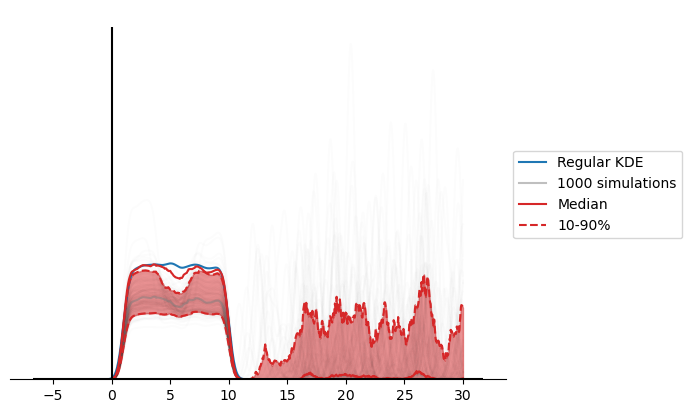

In [2365]:
fig, ax = plt.subplots()
kde2_plot(totals, ax)



In [2350]:
dict_analytics['all_weights'][:, 122:132]

array([[1.12030261e-01, 4.22702345e-04, 9.06637620e-03, ...,
        7.42171221e-03, 1.48066592e-02, 2.55708105e-02],
       [4.19340061e-03, 1.84971318e-02, 2.27253892e-01, ...,
        8.10004060e-03, 2.20783473e-02, 3.11713806e-02],
       [9.41275725e-03, 5.60894007e-02, 1.75518638e-02, ...,
        4.59118871e-02, 7.82038904e-02, 2.94302610e-02],
       ...,
       [9.60166882e-03, 1.03755400e-01, 2.14945365e-02, ...,
        6.92939150e-02, 3.19000193e-02, 1.74820743e-02],
       [1.33344357e-01, 1.87793537e-02, 5.92657147e-03, ...,
        6.32506715e-02, 5.32993328e-02, 4.79129983e-02],
       [1.28901585e-03, 2.55357216e-04, 2.87040492e-03, ...,
        2.95712495e-03, 3.75813873e-01, 6.16933765e-03]])

In [2351]:
dict_analytics['all_weights'].sum(axis=1)

array([1., 1., 1., ..., 1., 1., 1.])

# One-off testing

In [2321]:
data = np.random.uniform(1,10,122)
xvals = np.linspace(-5,30,1000)

group_constraints='auto'
W_base='auto'
bandwidths='auto'
W_confidence='auto'
target_mean=3
target_tol=1
represented='auto'
nruns=1001





No group constraints were provided
W_base has defaulted to uniform for all data points.
bandwidths has defaulted to the Silverman method for all data points.
W_confidence has defaulted to 0.5 for all data points. This means 50% of the weight for each data point will not move.
represented has defaulted to 0.6, indicating that this dataset represents 60% of all values


FOR LOOP PROGRESS: 100%|██████████| 1001/1001 [00:04<00:00, 236.74it/s]


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


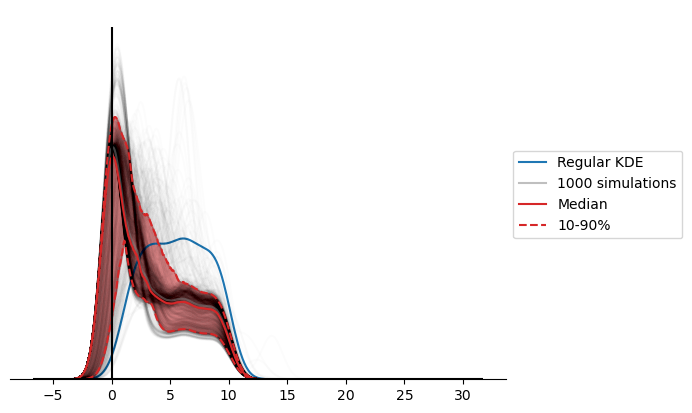

In [2322]:
fig, ax = plt.subplots()
kde2_plot(totals, ax)



In [2323]:
result = []
for X, W in zip(dict_analytics['all_values'], dict_analytics['all_weights']):
    result.append(sum(X*W))

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


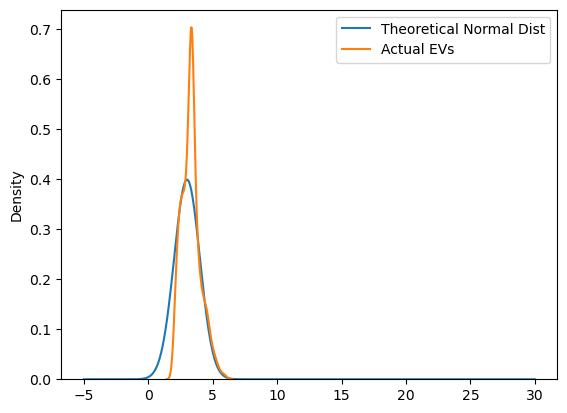

In [2326]:
fig, ax = plt.subplots()

yvals = norm.pdf(xvals, target_mean, target_tol)

ax.plot(xvals, yvals, label='Theoretical Normal Dist')
sns.kdeplot(result, label='Actual EVs')
ax.legend()